# EN.580.447 HW4 - Lillian Lam
## April 6, 2026

## Table of Contents
1. [Question 1: Cell Typing](#question-1)
    - 1.1 [Manual Annotations](#manual)
    - 1.2 [Removing VE](#remove)
    
2. [Question 2: Infer trajectory and pseudotime](#question-2)
    - 2.1 [Determine parameters and running scFates](#scfates)
    - 2.2 [Tree Visualization with Branches, Milestones, and Pseudotime](#validation)
    - 2.B [Validate the trajectory with biological priors](#prior)

3. [Question 3:  Discover regulators of differentiation](#question-3)
    - 3.1 [Branch-Specific Transcription Factors](#branch)
    - 3.2 [Rank TFs by Differentiation Potentials](#rankdiff)
    - 3.3 [Visualize and Discuss Top Candidate Regulators](#topdiff)

4. [Question 4: Discover regulators of pluripotency](#question-4)
    - 4.1 [TFs Downregulated Upon Differentiation](#downdiff)
    - 4.2 [Rank TFs by Pluripotency Score](#rankplur)
    - 4.3 [Visualize and Discuss Top Pluripotency Candidates](#topplur)

5. [Question 5: Compare CytoTRACE to pseudotime](#question-5)
    - 5.1 [Running CytoTRACE](#cyto)
    - 5.2 [CytoTRACE vs Pseudotime on UMAP and PCA](#graph)
    - 5.3 [Correlation Analysis](#corr)
    - 5.4 [CytoTRACE vs. Pseudotime Scatter Plot and Boxplot](#boxscat)
    - 5.5 [n_genes Correlation](#ngenes)
    - 5.6 [Results](#results)

---
**Acknowledgment:** Much of the code was taken from [Professor Patrick Cahan's scBasics notebook](https://github.com/compscbio/cscb2026/blob/gh-pages/notebooks/scBasics.ipynb),

[Professor Patrick Cahan's cell typing integration notebook](https://github.com/compscbio/cscb2026/blob/gh-pages/notebooks/cell_typing_integration.ipynb), and
[Professor Patrick Cahan's trajectory inference notebook](https://github.com/compscbio/cscb2026/blob/gh-pages/notebooks/scFates.ipynb)

<a id='question-1'></a>
# 1. Perform Cell-Typing

I manually switch the Colab environment to the 2025.07 runtime. This specific version provides the Python 3.11.13 environment. Go to ```Runtime``` -> ```Change Runtime``` -> ```Runtime Version``` -> ```2025.07```. This was done because there were issues with Python version of the Jupyter kernel that is actually executing the notebook's code staying in Python 3.12.

In [1]:
#required install in google colab
import sys
if 'google.colab' in sys.modules:
    print("Colab detected — installing required packages...")
    !pip uninstall numpy -y
    !pip install --upgrade numpy==1.26.4
    !pip install scanpy==1.10.3 anndata==0.10.8 scfates==1.0.9
    !pip install leidenalg==0.10.2 igraph==0.11.8
    !pip install pandas==2.2.0
    !pip install cellrank
    print("Local environment detected — skipping install.")

Colab detected — installing required packages...
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 31.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.4/124.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.7/421.7 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.0/187.0 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 13.3 MB/s eta 0:00:00
  Created w

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 121.7 MB/s eta 0:00:00
  Attempting uninstall: igraph
    Found existing installation: igraph 1.0.0
    Uninstalling igraph-1.0.0:
      Successfully uninstalled igraph-1.0.0
  Attempting uninstall: leidenalg
    Found existing installation: leidenalg 0.11.0
    Uninstalling leidenalg-0.11.0:
      Successfully uninstalled leidenalg-0.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
python-igraph 1.0.0 requires igraph==1.0.0, but you have igraph 0.11.8 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 34.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency re

In [1]:
import os, sys
os.environ['R_HOME'] = sys.exec_prefix+"/lib/R/"
print(os.environ['R_HOME'])

/usr/lib/R/


In [2]:
#required packages
import scanpy as sc
import scFates as scf
import numpy as np
import pandas as pd
import random
import igraph as ig
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cellrank as cr
import scanpy as sc
from scipy.stats import spearmanr
import seaborn as sns

In [3]:
#I uploaded the files to My Drive on google drive
from google.colab import drive
drive.mount('/content/drive')
adata = sc.read_h5ad("/content/drive/MyDrive/adHW4_2026.h5ad")

Mounted at /content/drive


<a id='manual'></a>
## 1.1 Identifying epiblast, mesoderm, anterior primitive streak, and visceral endoderm cells

## scRNA Sequencing Pipeline Function
I made the ```pipeline``` function to process the raw 10x Genomics data through quality control, normalization, clustering, and visualization. The function is designed to test how different parameter choices affect downstream results by allowing each step to be toggled on/off or modified independently. It is the same code from HW4, but using different markers.

### Pipeline Steps (things that can be altered are conditional)
1. Quality Control
    - Mitochondrial gene identification: Flags genes starting with "MT-" as mitochondrial
    - Ribosomal gene identification: Flags genes starting with "RPS" or "RPL" as ribosomal
    - QC metric calculation: Computes n_genes, total_counts, pct_counts_mt, pct_counts_ribo

    - Cell filtering (conditional):
      - Remove cells with high mitochondrial content (> threshold)
      - Remove cells with low gene counts (< min_genes)
      - Remove cells with high UMI counts (> max_counts) to eliminate doublets

    - Gene filtering: Removes genes detected in fewer than 10 cells

2. Normalization (conditional)
    - Library size normalization: Scales each cell to 10,000 total counts
    - Log transformation: Applies log1p transformation to stabilize variance

3. Highly Variable Gene Selection

    Identifies top 2000 genes with highest variance (heteroskedasticity) across cells. These genes are most informative for distinguishing different cell populations, while housekeeping genes that are expressed similarly across all cells contribute little discriminatory power.These genes will be used for downstream dimensionality reduction.

4. Dimensionality Reduction
    - PCA: Performs principal component analysis on highly variable genes
      - Many genes are correlated in their expression patterns, so there is redundancy in the data.
     - Allows us to capture the variance in the data, instead of the whole genome, making it computationally less exhausting

    - kNN graph (conditional):
      - If use_pcs=True: Uses first n_pcs principal components
      - If use_pcs=False: Uses full HVG expression matrix
      - creates an adjacency matrix by finding, for each cell, the k cells that are closest to it.
      - encodes the local structure of the data, which becomes the backbone of both UMAP and Leiden clustering.

5. Clustering and Visualization
    - UMAP: 2D visualization of cell relationships
    - Leiden clustering: Resolution: 0.5 for more finer clusers (to identify subtypes)

In [4]:
def pipeline(adata_raw, filter_mt=True, mt_threshold=20, filter_counts=True,
             max_counts=30000,filter_genes=True, min_genes=500, normalize=True,
             use_pcs=True, n_pcs=10, n_neighbors=20, leiden_resolution=0.5, silent=False, figure_size=(10,5)):


    np.random.seed(0)
    random.seed(0)


    #new copy each time
    adata = adata_raw.copy()

    # QUALITY CONTROL

    #mitochondrial genes
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    # ribosomal genes
    ribo_prefix = ('RPS', 'RPL')
    adata.var['ribo'] = adata.var_names.str.startswith(ribo_prefix)

    #calculate QC metrics to filter out mitocondrial data
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo'], percent_top=None, log1p=False, inplace=True)

    #filter cells based on parameters
    if filter_mt:
        adata = adata[adata.obs['pct_counts_mt'] < mt_threshold, :].copy()
    if filter_genes:
        sc.pp.filter_cells(adata, min_genes=min_genes)
    if filter_counts:
        sc.pp.filter_cells(adata, max_counts=max_counts)

    sc.pp.filter_genes(adata, min_cells=10)
    adata.var_names_make_unique()

    #NORMALIZATION

    if normalize:
        #proportion of reads for a gene relative to total library size
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        #store log-normalized data in a new layer
        adata.layers['lognorm'] = adata.X.copy()

    #IDENTIFY HIGHLY VARIABLE GENES

    sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='cell_ranger')

    #DIMENSIONAL REDUCTION & CLUSTERING

    sc.tl.pca(adata, mask_var='highly_variable')

    #kNN graph with or without pcs
    if use_pcs:
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, random_state=0)
    else:
        #use the full expression matrix (highly variable genes only)
        adata_hvg = adata[:, adata.var['highly_variable']].copy()
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep='X', random_state=0)

    #UMAP and Leiden clustering
    sc.tl.umap(adata, random_state=0)
    sc.tl.leiden(adata, resolution=leiden_resolution, flavor='igraph', n_iterations=2, random_state=0, key_added='leiden_cluster')

    #marker gene dictionary from homework 4
    marker_genes ={'Epiblast': ['Utf1', 'Slc7a3', 'Pou3f1'],
                   'Mesoderm': ['Mesp1', 'Fgf3', 'Snai1'],
                   'APS': ['Foxa2', 'Gsc', 'Sox17'],
                   'VE': ['Ttr', 'Afp', 'Eomes', 'Foxa1', 'Hhex', 'Cer1'] }

    #in case marker gene is not in the gene set
    filtered_markers = {}
    for cell_type, genes in marker_genes.items():
        present_genes = [g for g in genes if g in adata.var_names]
        if present_genes:
            filtered_markers[cell_type] = present_genes

    if not silent:
      sc.pl.umap(adata, color=['leiden_cluster'], legend_loc='on data', size=10, frameon=False)
      sc.tl.dendrogram(adata, groupby='leiden_cluster')
      #plot the dotplot to see if marker genes are expressd
      #helps to identify what cell type is in the cluster
      sc.pl.dotplot(adata, filtered_markers, groupby='leiden_cluster', dendrogram=True, var_group_rotation=45, figsize=figure_size)
      #violin plot to see the distribution of total gene expression per cluster
      sc.pl.violin(adata, ['total_counts'], groupby='leiden_cluster', rotation=90)

    return adata

Sources for th visceral endoderm markers:

For Afp:

Kwon, G. S., Viotti, M., & Hadjantonakis, A. K. (2008). The endoderm of the mouse embryo arises by dynamic widespread intercalation of embryonic and extraembryonic lineages. Developmental cell, 15(4), 509–520. https://doi.org/10.1016/j.devcel.2008.07.017

For Lefty1, Hex, and Cer1:

Takaoka, K., Yamamoto, M. & Hamada, H. Origin and role of distal visceral endoderm, a group of cells that determines anterior–posterior polarity of the mouse embryo. Nat Cell Biol 13, 743–752 (2011). https://doi.org/10.1038/ncb2251


For Eomes and Foxa1:

Nowotschin, S., Setty, M., Kuo, YY. et al. The emergent landscape of the mouse gut endoderm at single-cell resolution. Nature 569, 361–367 (2019). https://doi.org/10.1038/s41586-019-1127-1

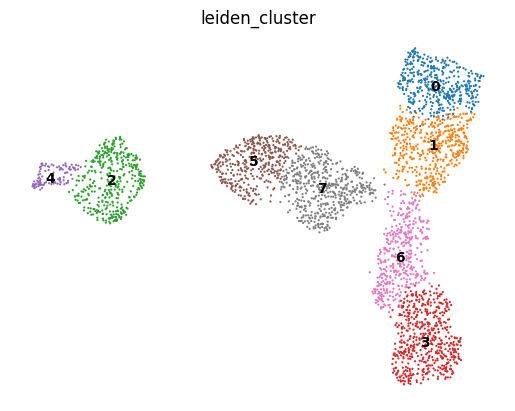

categories: 0, 1, 2, etc.
var_group_labels: Epiblast, Mesoderm, APS, etc.


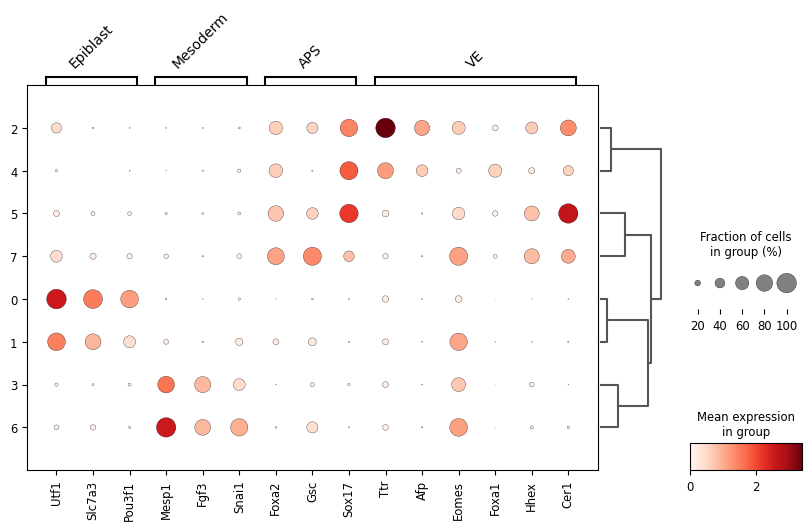

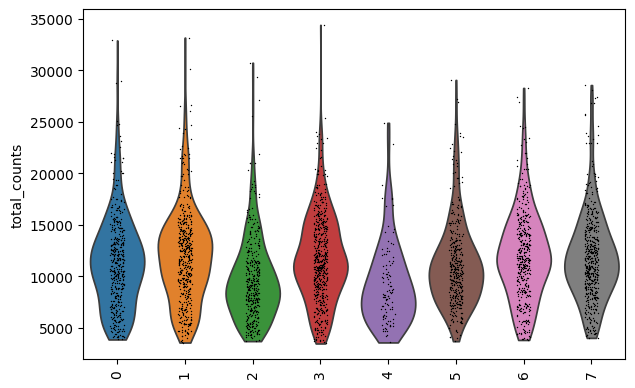

In [5]:
#cell QC already done
manual_annotation = pipeline(adata, filter_mt=False, filter_counts=False, filter_genes=False,)

### Cell Type Annotation Rationale

Epiblast (Cluster 0, 1): Highest mean expression of Utf1, Slc7a3, Pou3f1 with low expression of everything else

Mesoderm (Cluster 3, 6): Highest mean expession of Mesp1, Fgf3, Snai1 with low expression of everything else.

Anterior primitive streak (Cluster 5, 7): Had higher expression Foxa2, Gsc, and Sox17 with low expression of Ttr.

Visceral endoderm (Cluster 2, 4): Highest expression of Ttr and Afp with some expression of Hhex and Cer1



In [6]:
my_annotations= {'0': 'Epiblast',
                 '1':'Epiblast',
                 '2': 'Visceral endoderm',
                 '3': 'Mesoderm',
                 '4': 'Visceral endoderm',
                 '5': 'Anterior primitive streak',
                 '6': 'Mesoderm',
                 '7': 'Anterior primitive streak'}
manual_annotation.obs['manual_celltype'] = (manual_annotation.obs['leiden_cluster'].map(my_annotations).fillna('Unknown').astype(str))

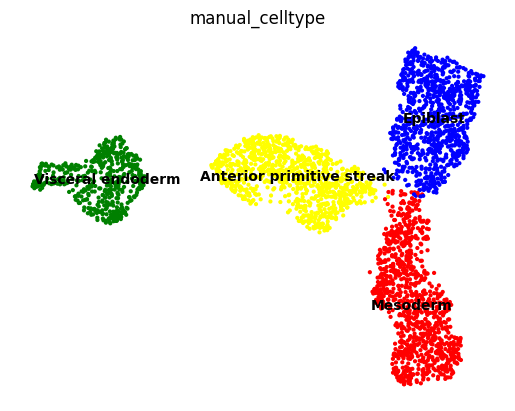

In [7]:
#visualize the clusters to see if the clusters are close together in UMAP space
sc.pl.umap(manual_annotation,
           color=['manual_celltype'],
           palette={'Epiblast': 'blue',
                    'Mesoderm': 'red',
                    'Anterior primitive streak': 'yellow',
                    'Visceral endoderm': 'green'},
           legend_loc='on data',
           frameon=False)

<a id='remove'></a>
## 1.2 Removing visceral endoderm from data

In [8]:
adata_filtered = manual_annotation[manual_annotation.obs['manual_celltype'] != 'Visceral endoderm'].copy()
print(adata_filtered.obs['manual_celltype'].value_counts())

manual_celltype
Mesoderm                     966
Epiblast                     916
Anterior primitive streak    896
Name: count, dtype: int64


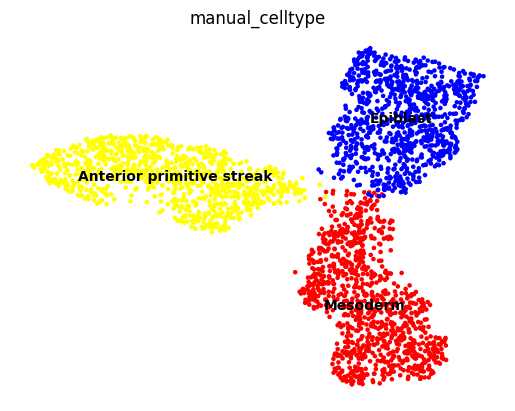

In [9]:
#visualize the clusters to see if VE is removed
sc.pl.umap(adata_filtered,
           color=['manual_celltype'],
           palette={'Epiblast': 'blue',
                    'Mesoderm': 'red',
                    'Anterior primitive streak': 'yellow'},
           legend_loc='on data',
           frameon=False)

 <a id='question-2'></a>
 # 2. Infer trajectory and pseudotime

### scFates (Trajectory Inference) Pipeline:

1. Prepare data for trajectory inference
   - create a copy of with VE-removed dataset (`adata_filtered`)
   - VE is a separate developmental lineage (not part of embryonic germ layers)
   
2. Identify highly variable genes and compute PCA
   - Select top 2000 HVGs using the Cell Ranger method.  
   - Run PCA on HVGs
   - Examine variance ratio plot to determine meaningful PCs.  
   - Use first 3 PCs, since PC1-PC3 capture the major lineage structure.

3. Validated PCA structure with marker genes
   - Plot PCA colored by manual annotations and markers (Utf1, Mesp1, Foxa2).  
   - Confirm expected separation:  
     - Epiblast (low PC1/PC2)  
     - Mesoderm (high PC1)  
     - APS (high PC2)

4. Grid search scFate parameters
   - I varied:  
     - `Nodes`: 10, 30, 50  
     - `ppt_lambda`: 1, 10, 50  
     - `ppt_sigma`: 0.1, 0.5, 1.0  
   - Fit principal trees using:  
     - `method='ppt'`  
     - `use_rep='X_pca'`  
     - `ndims_rep=3`  
   - Visualize each tree in PCA space to assess topology stability.

5. Select optimal principal tree configuration
   - Choose parameters that produce a clean Y-shaped trajectory.  
   - Final selected parameters:  
     - Nodes = 10
     - ppt_lambda = 50
     - ppt_sigma = 0.5
     - ndims_rep = 3  

6. identify the root the trajectory
   - identify principal point located deepest within the epiblast cluster.  
   - set node as the root using `scf.tl.root`.  

7. Compute pseudotime  
   - run `scf.tl.pseudotime` on the rooted tree.  
   - visualize pseudotime on PCA and on the principal graph.  
   - Confirm monotonic increase from epiblast to APS and epiblast to mesoderm.

8. Annotate milestones and segments  
   - extract milestone assignments and segment identities.  
   - compare with manual annotations to verify lineage ordering.  

9. Biological validation
   - Check marker gene expression along pseudotime:  
     - Utf1 decreases along both branches
     - Mesp1 increases along mesoderm branch
     - Foxa2 increases along APS branch




<a id='scfates'></a>
## 2.1 Determine parameters and running scFates

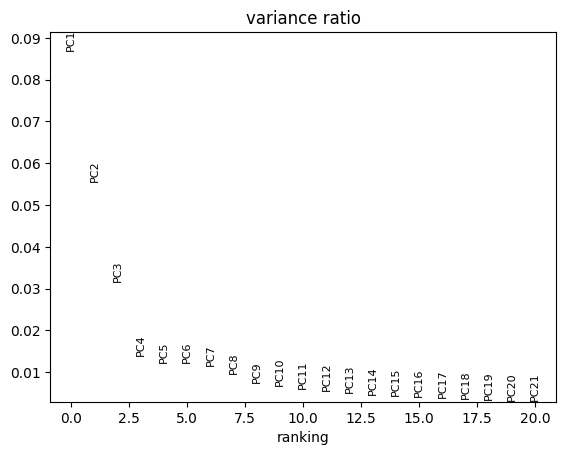

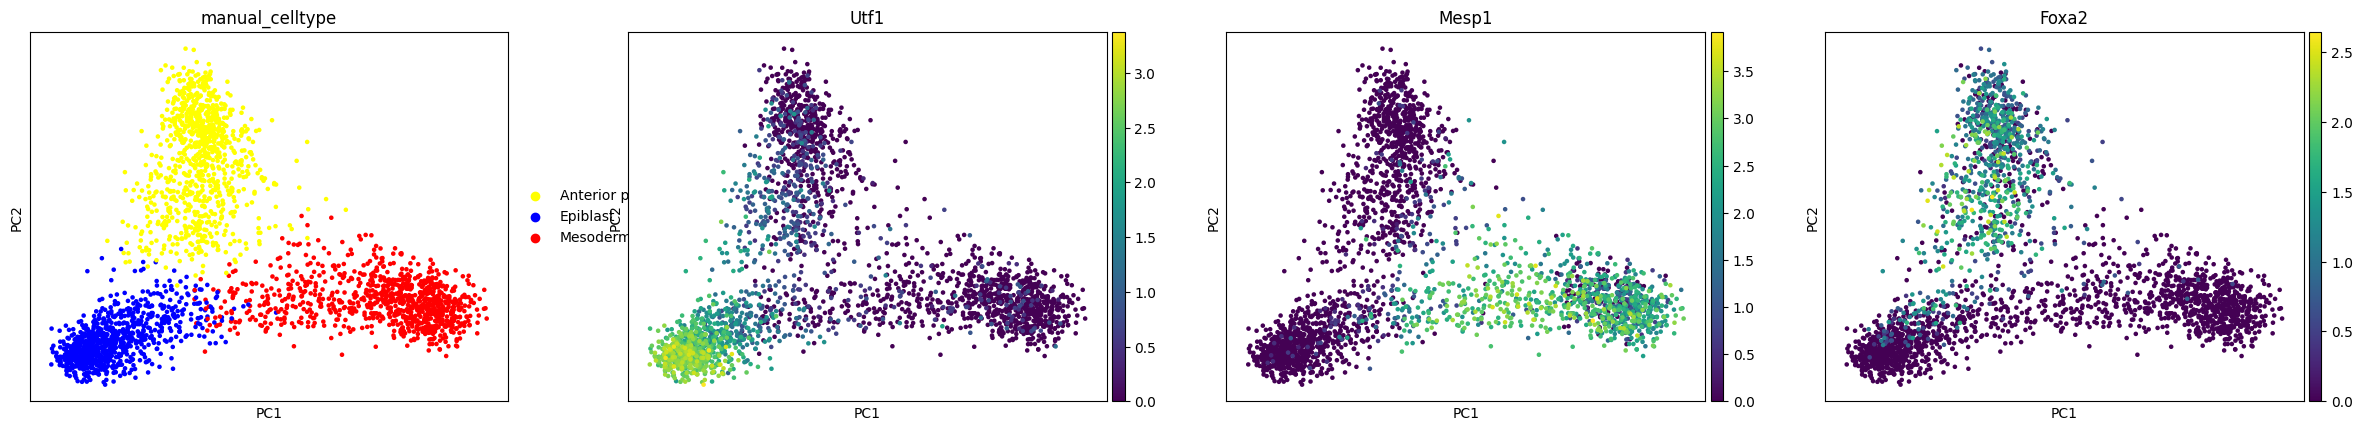

In [10]:
adata_ti = adata_filtered.copy()

sc.pp.highly_variable_genes(adata_ti, n_top_genes=2000, flavor='cell_ranger')
sc.tl.pca(adata_ti, mask_var='highly_variable')

#look to see the number of PC that capture meaningful variance with scree plot
sc.pl.pca_variance_ratio(adata_ti, n_pcs=20)

#color by cell type markers to confirm structure before fitting tree
sc.pl.pca(adata_ti, color=['manual_celltype','Utf1', 'Mesp1', 'Foxa2'])

#### From the variance ratio plot:

The elbow is sharp and occurs right after PC3. PC1 (0.09), PC2 (0.06), and PC3 (0.03) carry substantially more variance than PC4 onward, which all flatten out below 0.02.
From the PCA plots, this is biologically confirmed that the three cell types separate cleanly in PC1 vs PC2 already.

#### Loadings:

Epiblast (blue) sits at the bottom left - low PC1, low PC2

APS (yellow) is at the top - high PC2

Mesoderm (red) is at the bottom right - high PC1, low PC2

#### The marker genes also validate this separation:

Utf1 is high in epiblast (bottom left)

Mesp1 is high in the bottom right cluster, which appears to be the mesoderm

Foxa2 is high in the upper cluster consistent with APS

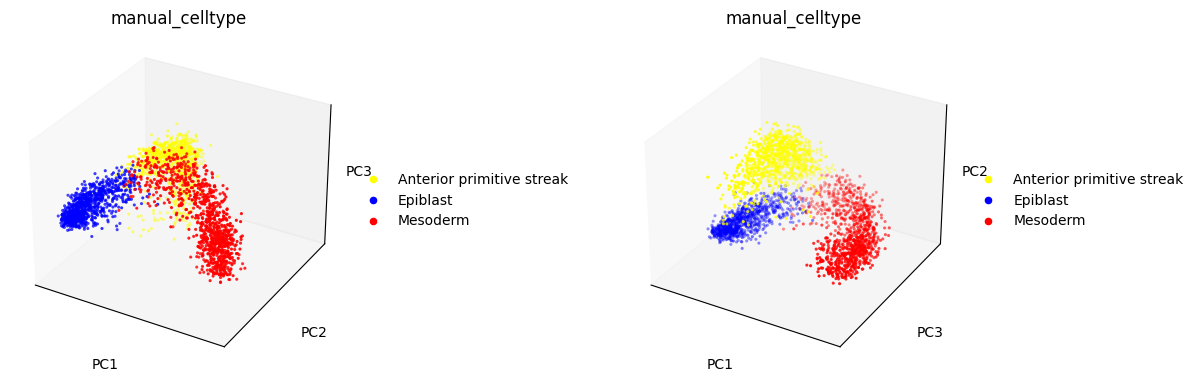

In [12]:
sc.pl.pca(adata_ti, color=['manual_celltype'], projection='3d', components=['1,2,3','1,3,2'])

inferring a principal tree --> parameters used 
    10 principal points, sigma = 0.1, lambda = 1, metric = euclidean
    fitting: 100%|██████████| 50/50 [00:00<00:00, 53.22it/s]
    not converged (error: 0.03954281952593353)
    finished (0:00:00) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.
inferring a principal tree --> parameters used 
    10 principal points, sigma = 0.5, lambda = 1, metric = euclidean
    fitting: 100%|██████████| 50/50 [00:00<00:00, 254.93it/s]
    not converged (error: 0.015012640996377502)
    finished (0:00:00) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates

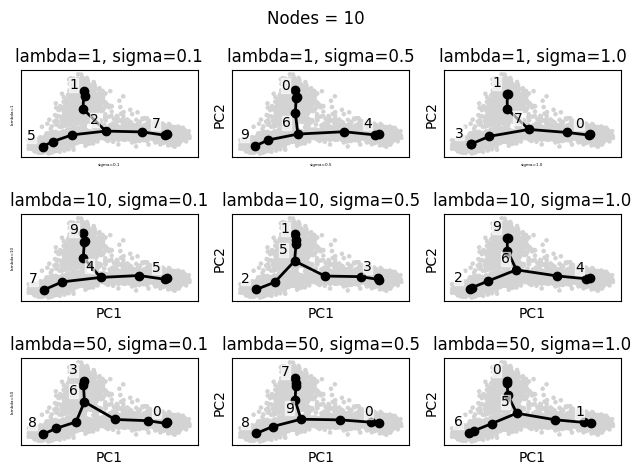

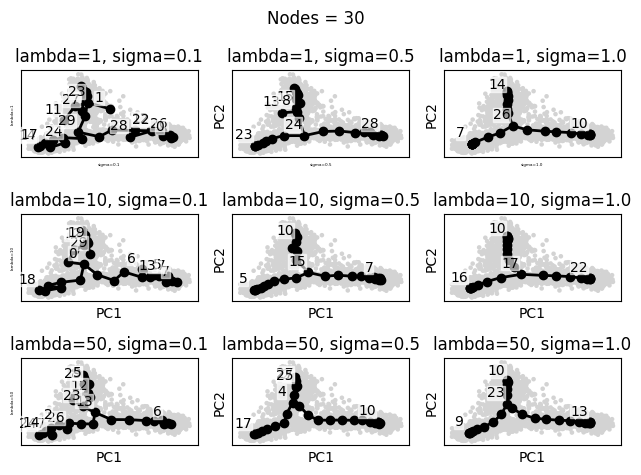

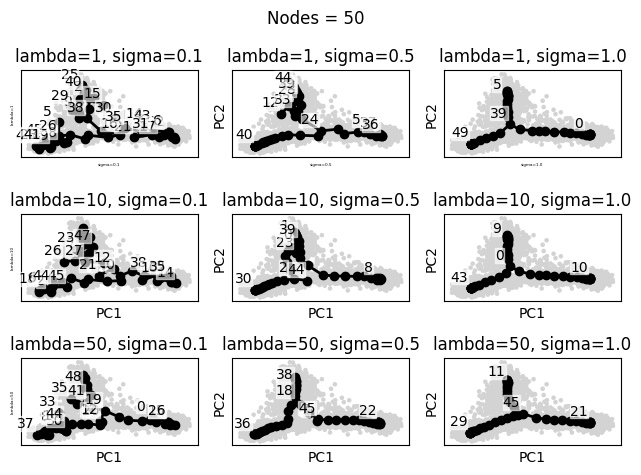

In [13]:
#parameters to vary
lambdas = [1, 10, 50]
sigmas = [0.1, 0.5, 1.0]
node_counts = [10, 30, 50]

np.random.seed(0)
random.seed(0)

#we loop over the number of nodes
for n_nodes in node_counts:
    fig, axes = plt.subplots(len(lambdas), len(sigmas))
    fig.suptitle(f'Nodes = {n_nodes}')

    for i, lam in enumerate(lambdas):
        for j, sig in enumerate(sigmas):
          #fit a prinicple tree for each lambda and sigma
            scf.tl.tree(adata_ti,
                        method='ppt',
                        Nodes=n_nodes,
                        use_rep='X_pca',
                        ndims_rep=3,
                        ppt_lambda=lam,
                        ppt_sigma=sig,
                        random_state=0)
            #look at the TI in pca space to see if it makes sense biologically
            ax = scf.pl.graph(adata_ti, basis='pca', show=False, ax=axes[i,j])
            ax.set_title(f'lambda={lam}, sigma={sig}')

            if j == 0:
                ax.set_ylabel(f'lambda={lam}', fontsize=3)
            if i == 0:
                ax.set_xlabel(f'sigma={sig}', fontsize=3)
    plt.tight_layout()

To fit the principal tree to the gastrulation data, I looked at the different parameters: number of principal points (Nodes = {10, 30, 50}), elasticity penalty (lambda = {1, 10, 50}), and locality of principal points (sigma = {0.1, 0.5, 1.0}). The number of principal components used as input was set to 3, justified by a clear elbow in the PCA variance ratio plot after PC3, and confirmed by the clean separation of epiblast, anterior primitive streak, and mesoderm populations in PC1-PC2 space.

With 10 nodes, the model was able to capture the overall Y-shaped branching structure. Although 30 and 50 nodes also worked, they did not meaningfully improve the trajectory and added unnecessary complexity.

The sigma parameter controls how much each node is influenced by nearby cells. When sigma was too small (0.1), the tree became noisy and bends too much around the APS. When sigma was too large (1.0), the branches were overly smoothed and pulled toward the center. The APS branch was pulled disproportionately toward the center, causing it to shrink and lose resolution. A middle value (sigma = 0.5) gave the best balance.

The APS population sits close to the Epiblast-Mesoderm axis in PC space, making it easy for a flexible tree to get confused about directionality. When lambda=1, the APS branch curves towards the mesoderm clusters at the end, meaning pseudotime would be assigned in the wrong direction for APS cells, which is biologically incorrect since APS is a terminal population. A higher lambda forces the branches to be more linearly ordered, which actually better reflects the known biology, as gastrulation proceeds in a usually smooth, directed manner from epiblast outward.

 Overall, I selected ```Nodes=10```, ```ppt_lambda=50```, and ```ppt_sigma = 0.5``` because this combination provided a clear, stable, and well-resolved Y-shaped trajectory connecting the three cell populations.

inferring a principal tree --> parameters used 
    10 principal points, sigma = 0.5, lambda = 50, metric = euclidean
    fitting:  62%|██████▏   | 31/50 [00:01<00:00, 30.59it/s]
    converged
    finished (0:00:01) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.


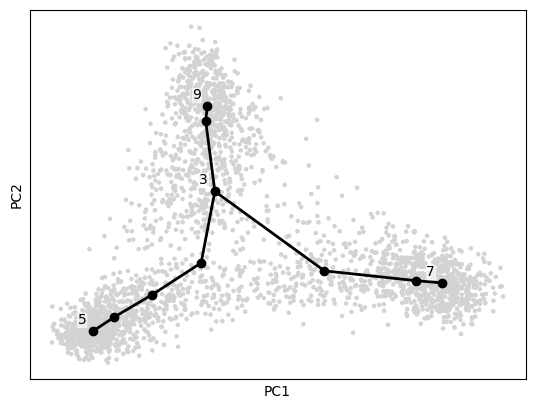

In [24]:
#running tl.tree to make the branch stucture with final parameters
np.random.seed(0)
random.seed(0)
scf.tl.tree(adata_ti,
            method='ppt',
            Nodes=10,
            use_rep='X_pca',
            ndims_rep=3,
            ppt_lambda=50,
            ppt_sigma=0.5,
            random_state=0)

scf.pl.graph(adata_ti, basis='pca')

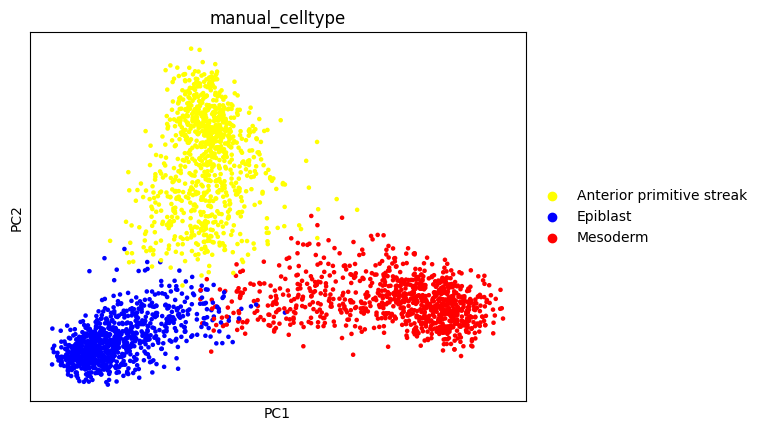

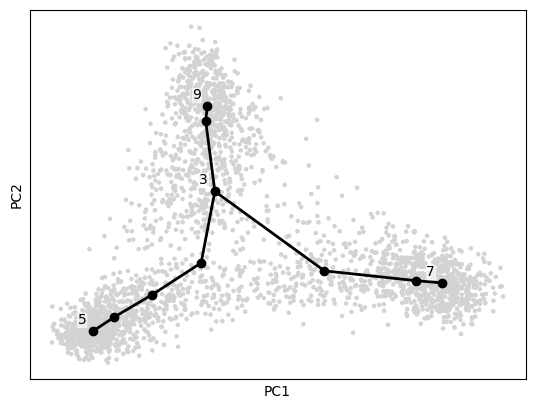

In [25]:
#showing the PCA plot next to the TI to check the epiblast
#helps determine the root node for the TI
sc.pl.pca(adata_ti, color='manual_celltype')
scf.pl.graph(adata_ti, basis='pca')

In [26]:
#root is node deepest within the epiblast cluster,
#since epiblast cells are the progenitors of both APS and mesoderm.
#it is node 5 from the graph above
scf.tl.root(adata_ti, 5)

node 5 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.


<a id='validation'></a>
## 2.2 Tree Visualization with Branches, Milestones, and Pseudotime

projecting cells onto the principal graph
    finished (0:00:03) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


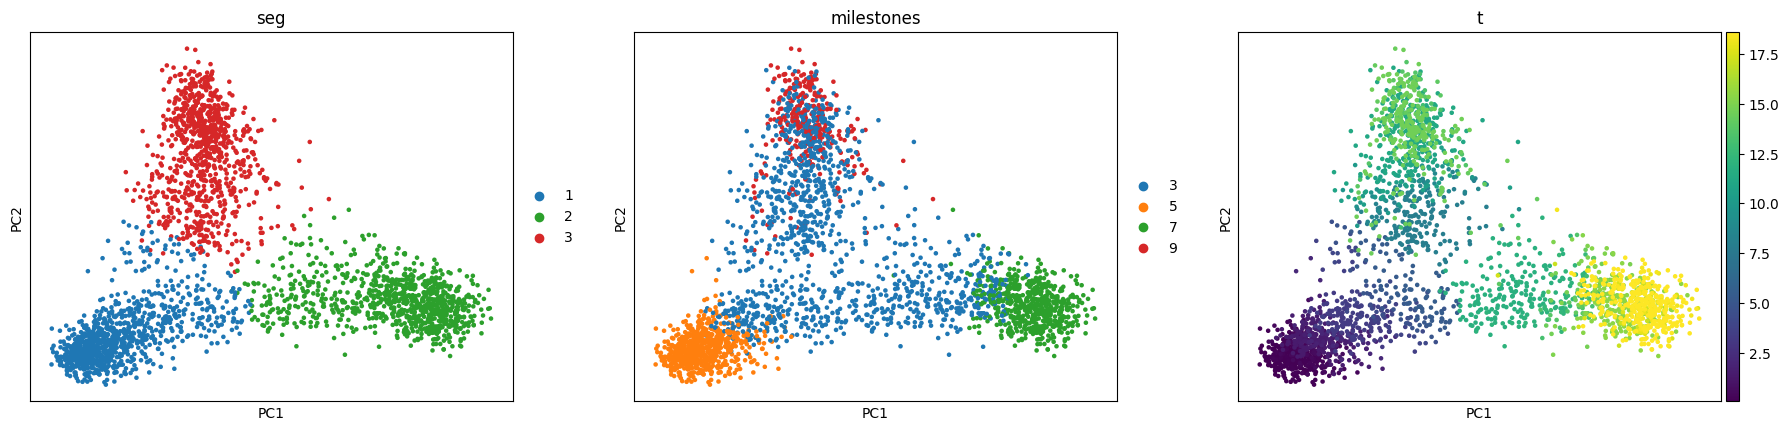

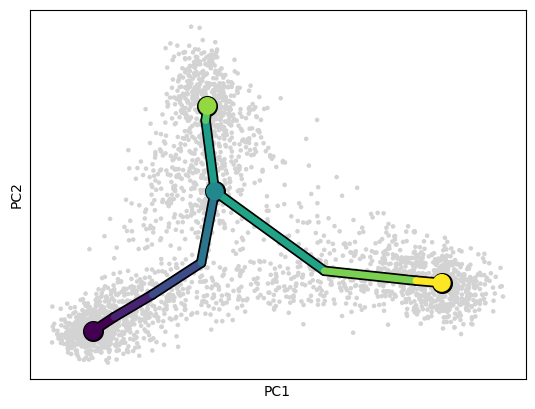

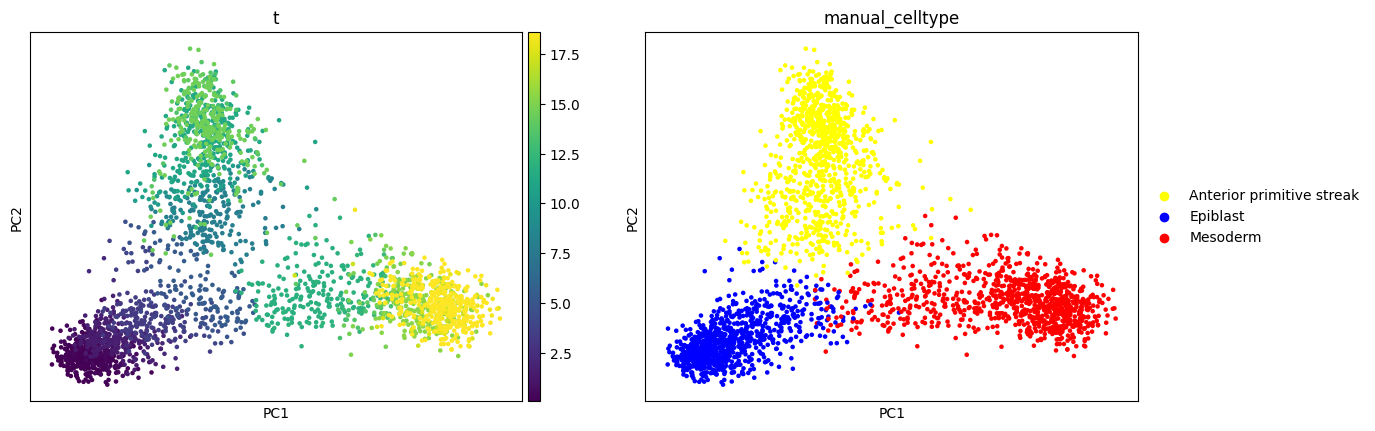

In [27]:
np.random.seed(0)
random.seed(0)
scf.tl.pseudotime(adata_ti, seed=0)

#show segments and milestones
sc.pl.pca(adata_ti, color=['seg', 'milestones', 't'])

#overlay the trajectory with pseudotime coloring
scf.pl.trajectory(adata_ti, basis='pca')

#overlay PCA colored by pseudotime and cell type side to side
sc.pl.pca(adata_ti, color=['t', 'manual_celltype'])

I displayed which branch (segment) each cell belongs to, identified key decision points (milestones) along the trajectory, and visualized pseudotime values across cells. The segments follow similar clustering to my manual annotations, with most misassignments occurring near the transitional region between epiblast and APS or epiblast and mesoderm. This is biologically expected, as cells undergoing EMT and ingressing through the primitive streak are in the process of committing to a fate and may display markers from both populations simultaneously. The milestones has a cluster that shows the transitional area between epliblast, APS, and mesoderm.

```scf.pl.trajectory(adata_ti, basis='pca')``` overlays the inferred tree onto PCA space with cells colored by pseudotime, confirming that pseudotime increases smoothly along both branches away from the epiblast root. The TI also shows that max mesoderm psuedotime is about a 2.5 pseudotime longer than the APS cells (about 15 in pseudotime).

```sc.pl.pca(adata_ti, color=['t', 'manual_celltype'])``` cross-validates pseudotime against my manual cell type annotations. We see that pseudotime increases progressively from Epiblast to terminal fates (APS and mesoderm), which consistent with the known developmental order during gastrulation.

manual_celltype  Anterior primitive streak  Epiblast  Mesoderm
milestones                                                    
3                                      578       240       367
5                                        0       676         0
7                                        1         0       599
9                                      317         0         0
manual_celltype  Anterior primitive streak  Epiblast  Mesoderm
seg                                                           
1                                       43       915        41
2                                        2         1       923
3                                      851         0         2
Generating dendrogram of tree
    segment : 100%|██████████| 3/3 [00:16<00:00,  5.37s/it]
    finished (0:00:16) --> added 
    .obsm['X_dendro'], new embedding generated.
    .uns['dendro_segments'] tree segments used for plotting.


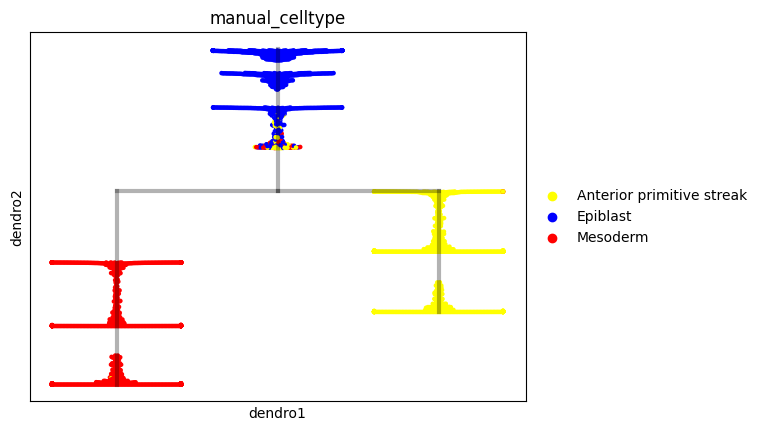

In [18]:
#determine how many of each cell type is within a cluster in branch and milestone
print(adata_ti.obs.groupby(['milestones', 'manual_celltype'], observed=False).size().unstack())
print(adata_ti.obs.groupby(['seg', 'manual_celltype'], observed=False).size().unstack())

#dendrogram to show the hierarchical relationships between milestones in the inferred trajectory.
scf.tl.dendrogram(adata_ti)
scf.pl.dendrogram(adata_ti, color=['manual_celltype'])

In [19]:
#segment IDs for each branch
epiblast_seg= '1'
mesoderm_seg= '2'
aps_seg= '3'

#milstone IDs for each branch
epiblast_mil='5'
mesoderm_mil='7'
aps_mil='9'
mixed_transitional_mil='3'

The milestone assignment table shows that milestone 5 contains exclusively Epiblast cells (676 cells), serving as the root of the trajectory. Milestone 7 consists primarily of Mesoderm cells (599 cells), while milestone 9 contains exclusively Anterior primitive streak cells (317 cells), confirming these as terminal branch points. A transitional milestone (milestone 3) contains a mix of all three cell types (578 APS, 367 Mesoderm, 240 Epiblast), representing the branch point where cells are actively committing to their terminal fates, which is consistent with cells undergoing EMT and ingressing through the primitive streak.

The segment assignment table further validates the branch structure, with segment 1 containing predominantly Epiblast (915 cells), segment 2 containing predominantly Mesoderm (923 cells), and segment 3 containing predominantly APS (851 cells).

The dendrogram reveals that Epiblast clusters separately from the differentiated populations. From this epiblast root, the two major developmental lineages, Mesoderm and APS, diverge into separate terminal branches. The Mesoderm and APS clades are well separated (no mislabeled in the clusters), indicating strong transcriptional divergence between these fates. We do see that there is some mixing at end of pseudotime in the Epiblast branch, which might be cells that are transitioning. The Mesoderm branch appears slightly longer than the APS branch in pseudotime space, suggesting that mesoderm differentiation may require more transcriptional remodeling compared to the APS fate. This is supported by the fact that APS requires less pseudotime to differenciate. Overall, the dendogram shows that the inferred Y-shaped trajectory accurately captures the known developmental progression from epiblast to mesoderm and anterior primitive streak during gastrulation.

<a id='prior'></a>
## 2.B Validating the trajectory with priors in dataset


test features for association with the trajectory
    single mapping : 100%|██████████| 2000/2000 [06:01<00:00,  5.53it/s]
    found 81 significant features (0:06:01) --> added
    .var['p_val'] values from statistical test.
    .var['fdr'] corrected values from multiple testing.
    .var['st'] proportion of mapping in which feature is significant.
    .var['A'] amplitue of change of tested feature.
    .var['signi'] feature is significantly changing along pseudotime.
    .uns['stat_assoc_list'] list of fitted features on the graph for all mappings.
fit features associated with the trajectory
    single mapping : 100%|██████████| 81/81 [00:33<00:00,  2.44it/s]
    finished (adata subsetted to keep only fitted features!) (0:00:33) --> added
    .layers['fitted'], fitted features on the trajectory for all mappings.
    .raw, unfiltered data.


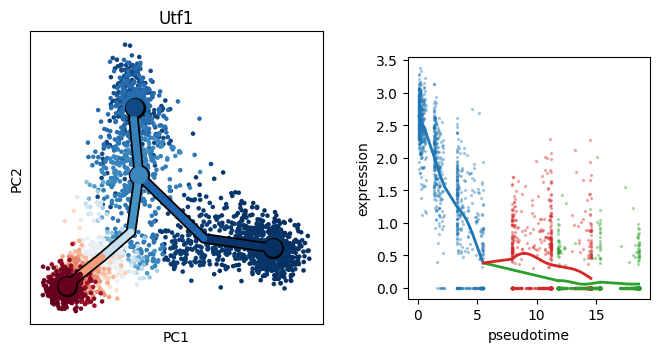

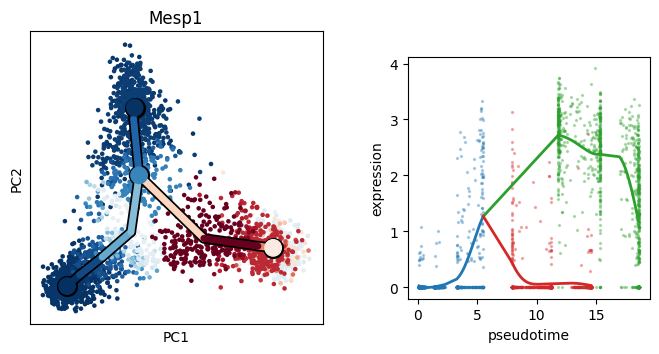

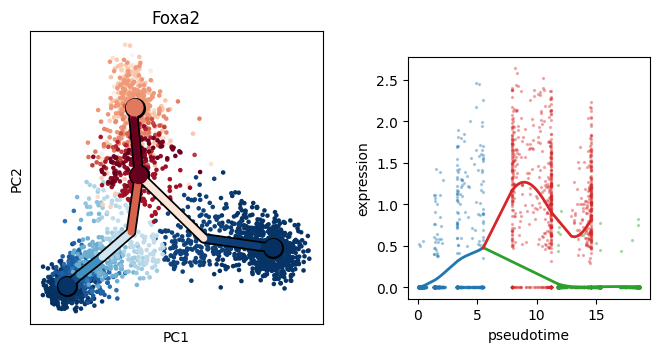

In [21]:
ad_ti_check= adata_ti[:, adata_ti.var['highly_variable']].copy()
scf.tl.test_association(ad_ti_check, n_jobs=-1)
scf.tl.fit(ad_ti_check, n_jobs=-1)

scf.pl.single_trend(ad_ti_check, 'Utf1', basis='pca')
scf.pl.single_trend(ad_ti_check, 'Mesp1', basis='pca')
scf.pl.single_trend(ad_ti_check, 'Foxa2', basis='pca')

After selecting the highly variable genes that best capture the structure of the trajectory, I created a smaller AnnData object `ad_ti_check` containing only HVGs. This reduces noise and ensures that downstream analyses focus on biologically meaningful variation. I then ran `scf.tl.test_association` to test if gene expression changes along pseudotime. This step identifies genes that are dynamically regulated during differentiation. Next, I used `scf.tl.fit` to smooth each gene's expression pattern along the principal tree so that I can see the trends og each gene. I plotted single-gene trends for Utf1, Mesp1, and Foxa2 using `scf.pl.single_trend`, which overlays each gene's expression on both the PCA embedding and the pseudotime axis. These plots reveal expected developmental dynamics: Utf1 decreases as cells leave the epiblast state, Mesp1 increases along the mesoderm branch, and Foxa2 increases along the APS branch, confirming that the inferred trajectory captures biologically meaningful differentiation paths. I want to note that for Mesp1 and Foxa2: as the cell leaves the epiblast state, Mesp1 and Foxa2 initially increase, but after the cell commits to what it wants to be, Foxa2 decreases for the mesoderm branch and Mesp1 decreases in the APS.


Although embryonic stage labels (E6.5, E7.5, E8.5) were not available in this dataset, I can still describe the expected relationship between pseudotime and developmental stage. In a typical gastrulation timecourse, E6.5 cells (primitive streak initiation) would occupy the lowest pseudotime values, E7.5 cells (active gastrulation, neural plate/headfold stage) would occupy intermediate values, and E8.5 cells (early somite stages, germ layer establishment) would occupy the highest values. The inferred Y-shaped trajectory from this analysis seems biologically plausible because: epiblast (root) corresponds to the earliest developmental state, pseudotime increases monotonically along both branches, and the branching structure shows the lineage divergence of mesoderm and APS. While I cannot directly confirm the stage relationships without labels, the strong agreement between pseudotime ordering and known marker gene dynamics (Utf1 decreasing, Mesp1 and Foxa2 increasing in their respective branches) validates that the trajectory correctly orders cells from less differentiated (epiblast) to more differentiated (mesoderm/APS). This provides confidence that the pseudotime reflects relative developmental progression, even if absolute stage cannot be determined.

Source:

Aguilera-Castrejon, A., Oldak, B., Shani, T. et al. Ex utero mouse embryogenesis from pre-gastrulation to late organogenesis. Nature 593, 119–124 (2021). https://doi.org/10.1038/s41586-021-03416-3

<a id='question-3'></a>
# 3. Discover regulators of differentiation

###  TF Ranking Pipeline for Differentiation Regulators

#### Ranking Criteria:

1. p-value
   - I used `scf.tl.test_association` to find genes whose expression is significantly associated with pseudotime along each branch
   - Lower p-value = stronger association with differentiation

2. Branch specificity
   - TF should be enriched in one branch relative to the other
   - computed as the difference in mean log-normalized expression between mesoderm and APS branches
   - A TF that is high in both branches is less informative as a lineage-specific regulator

3. Fold change from epiblast
   - TFs strongly upregulated in the terminal population relative to the epiblast root are more likely to be active drivers of differentiation
   - these TFs are turned on as cells differentiate

4. Composite score
   - Combines -log10(p-value), branch specificity, and fold change into a single ranking score per branch with equal weights

#### Processing Steps:

1. load TF list from file (`mouse_tfs_aertslab.txt`)
2. check overlap with genes in the dataset (sanity check)
3. `scf.tl.test_association` on HVGs each gene's expression changes along pseudotime
4. `scf.tl.test_fork` to get genes are differentially expressed between branches
5. determined genes with FDR < 0.05 as significance threshold
6. looked at branch-specific expression using log-normalized data
7. Build ranking dataframe with:
   - mean expression per branch (mesoderm, APS, epiblast)
   - fold change from epiblast
   - branch specificity scores
   - composite scores for mesoderm and APS branches
8. Select top TFs meeting all criteria:
   - FDR < 0.05 (statistically significant with no false positives)
   - Fold change from epiblast > 0 (upregulated in terminal population)
   - Branch specificity > 0 (higher in target branch)
9. Visualize top TFs using:
   - `scf.pl.trends` for expression along pseudotime
   - `sc.pl.dotplot` for expression across cell types
   - `sc.pl.pca` colored by TF expression




<a id='branch'></a>
## 3.1 Branch-Specific Transcription Factors


In [22]:
#load TF list from file (one gene per line, no header)
with open('/content/drive/MyDrive/mouse_tfs_aertslab.txt', 'r') as f:
    tf_list = set([line.strip() for line in f if line.strip()])

print(f'Total TFs in reference list: {len(tf_list)}')

#check overlap with genes in the dataset
tf_in_data = [tf for tf in tf_list if tf in adata_ti.var_names]
print(f'\nTFs present in dataset: {len(tf_in_data)}')

Total TFs in reference list: 1860

TFs present in dataset: 1408


In [23]:
np.random.seed(0)
random.seed(0)

adata_hvg = adata_ti[:, adata_ti.var['highly_variable']].copy()
print(f'Testing {adata_hvg.n_vars} highly variable genes')

scf.tl.test_association(adata_hvg, reapply_filters=False, n_jobs=2)
scf.tl.test_fork(adata_hvg, root_milestone=epiblast_mil, milestones=[mesoderm_mil, aps_mil], n_jobs=2)

#shows first 10 genes
print(adata_hvg.var[['fdr', 'st', 'A']].head(10))
#check to see the columns names for the ranking code
print(f'Columns available: {adata_hvg.var.columns.tolist()}')

Testing 2000 highly variable genes
test features for association with the trajectory
    single mapping : 100%|██████████| 2000/2000 [04:55<00:00,  6.76it/s]
    found 81 significant features (0:04:55) --> added
    .var['p_val'] values from statistical test.
    .var['fdr'] corrected values from multiple testing.
    .var['st'] proportion of mapping in which feature is significant.
    .var['A'] amplitue of change of tested feature.
    .var['signi'] feature is significantly changing along pseudotime.
    .uns['stat_assoc_list'] list of fitted features on the graph for all mappings.
testing fork
    single mapping
    Differential expression: 100%|██████████| 2000/2000 [07:45<00:00,  4.30it/s]
    test for upregulation for each leave vs root
    upreg 9: 100%|██████████| 1232/1232 [00:09<00:00, 124.83it/s]
    finished (0:08:02) --> added 
    .uns['5->7<>9']['fork'], DataFrame with fork test results.
                         fdr  st         A
Sox17           0.000000e+00   1  2.30648

Sox17 showing extremely strong association with pseudotime (FDR~0, st = 1, A = 2.31) is a good sign, as this TF that we used to define the APS cells in part 1.

<a id='rankdiff'></a>
## 3.2 Rank TFs by Differentiation Potentials

In [24]:
#look for FDR < 0.05
sig_genes= adata_hvg.var[adata_hvg.var['fdr'] < 0.05].index.tolist()
print(f'Significant genes (FDR < 0.05): {len(sig_genes)}')

#filter to only TF list genes
sig_tfs = [g for g in sig_genes if g in tf_list]
print(f'Significant TFs: {len(sig_tfs)}')

Significant genes (FDR < 0.05): 1143
Significant TFs: 186


In [25]:
#we want to look at the log-normalized expression matrix to account for library size differences and heteroscedasticity
lognorm= pd.DataFrame(adata_hvg.layers['lognorm'].toarray(),
                       index=adata_hvg.obs_names,
                       columns=adata_hvg.var_names)

#mean expression per branch for significant TFs only
meso_cells= adata_hvg.obs[adata_hvg.obs['seg'] == mesoderm_seg].index
aps_cells= adata_hvg.obs[adata_hvg.obs['seg'] == aps_seg].index
epi_cells= adata_hvg.obs[adata_hvg.obs['manual_celltype'] == 'Epiblast'].index

mean_meso=lognorm.loc[meso_cells, sig_tfs].mean()
mean_aps=lognorm.loc[aps_cells, sig_tfs].mean()
mean_epi=lognorm.loc[epi_cells, sig_tfs].mean()

In [26]:
tf_stats = pd.DataFrame({'gene': sig_tfs,
                         'fdr': adata_hvg.var.loc[sig_tfs, 'fdr'],
                         'mean_meso': mean_meso.values,
                         'mean_aps': mean_aps.values,
                         'mean_epi': mean_epi.values,}).set_index('gene')

#fold change from epiblast
tf_stats['fc_meso'] = tf_stats['mean_meso']-tf_stats['mean_epi']
tf_stats['fc_aps']  = tf_stats['mean_aps']-tf_stats['mean_epi']

#branch specificity: higher = more specific to that branch
#we are measuring whether a TF is enriched in one branch vs the other
tf_stats['specificity_meso']= tf_stats['mean_meso']-tf_stats['mean_aps']
tf_stats['specificity_aps'] = tf_stats['mean_aps']-tf_stats['mean_meso']

#transform p-values to a more interpretable scale (similar to vocano plot)
#small epsilon to avoid log(0)
eps= 1e-6
tf_stats['neg_log10_fdr']= -np.log10(tf_stats['fdr']+eps)

#combine three criteria into one ranking score (I decided to just make everything equal weights)
tf_stats['score_meso'] = (tf_stats['neg_log10_fdr'] + tf_stats['fc_meso'] + tf_stats['specificity_meso'])
tf_stats['score_aps'] = (tf_stats['neg_log10_fdr'] + tf_stats['fc_aps'] + tf_stats['specificity_aps'])


In [27]:
#get the top 10 transcription factor candidates for mesoderm and APS differentiation
top_meso_tfs = (tf_stats[(tf_stats['fc_meso']>0) & (tf_stats['specificity_meso'] > 0)].sort_values('score_meso', ascending=False).head(10))
top_aps_tfs = (tf_stats[(tf_stats['fc_aps']>0) & (tf_stats['specificity_aps'] > 0)].sort_values('score_aps', ascending=False).head(10))

print('Top Mesoderm TFs:\n')
print(top_meso_tfs[['fdr', 'fc_meso', 'specificity_meso', 'score_meso']])

print('\nTop APS TFs:\n')
print(top_aps_tfs[['fdr', 'fc_aps', 'specificity_aps', 'score_aps']])

Top Mesoderm TFs:

                  fdr   fc_meso  specificity_meso  score_meso
gene                                                         
Phlda2   0.000000e+00  2.700762          2.624076   11.324838
Mesp1    0.000000e+00  1.894332          1.877391    9.771723
Hand1    0.000000e+00  0.959910          0.958156    7.918066
Rbms1    0.000000e+00  1.082118          0.520250    7.602368
Etv2    3.820766e-265  0.719344          0.744612    7.463957
Msx2     0.000000e+00  0.663495          0.638598    7.302093
Msx1    1.525847e-219  0.685175          0.496003    7.181178
Snai1    0.000000e+00  0.565229          0.614140    7.179370
Foxf1    0.000000e+00  0.590764          0.586045    7.176808
Id1     1.165541e-130  0.744445          0.392415    7.136860

Top APS TFs:

                  fdr    fc_aps  specificity_aps  score_aps
gene                                                       
Sox17    0.000000e+00  1.440796         1.428628   8.869424
Lhx1     0.000000e+00  1.242552         0.

The identification of Mesp1 as the 2nd-ranked mesoderm TF, and Sox17 as the top-ranked APS TF validates my trajectory and ranking pipeline. Both are well-established master regulators of their respective lineages, and their appearance at the top of the lists, along with other known lineage-specific TFs such as Hand1, Snai1, Foxa2, and Gsc (given in the HW4 problem 1 to identify the cell types), shows that my composite scoring system successfully recovered biologically meaningful differentiation drivers. The fact that all top candidates show FDR of approximately 0, positive fold change from epiblast, and positive branch specificity further confirms that my trajectory likely captures lineage-specific gene activation during gastrulation.

<a id='topdiff'></a>
## 3.3 Visualize and Discuss Top Candidate Regulators

fit features associated with the trajectory
    single mapping : 100%|██████████| 81/81 [00:53<00:00,  1.50it/s]
    finished (adata subsetted to keep only fitted features!) (0:00:53) --> added
    .layers['fitted'], fitted features on the trajectory for all mappings.
    .raw, unfiltered data.


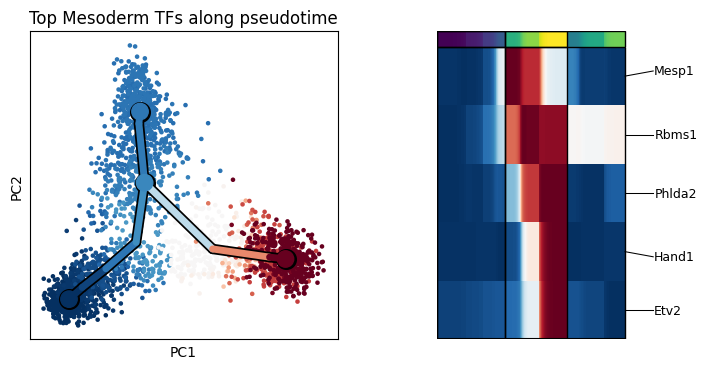

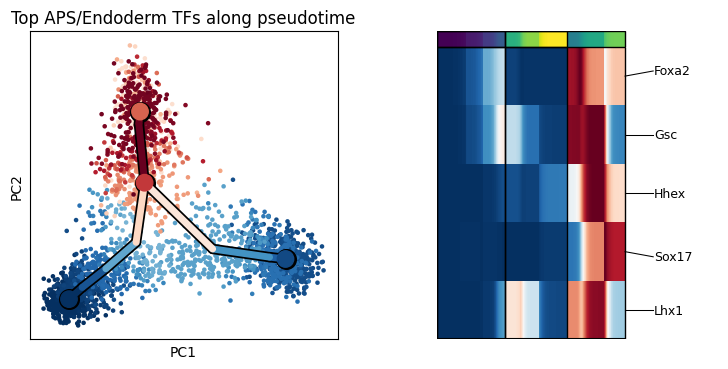

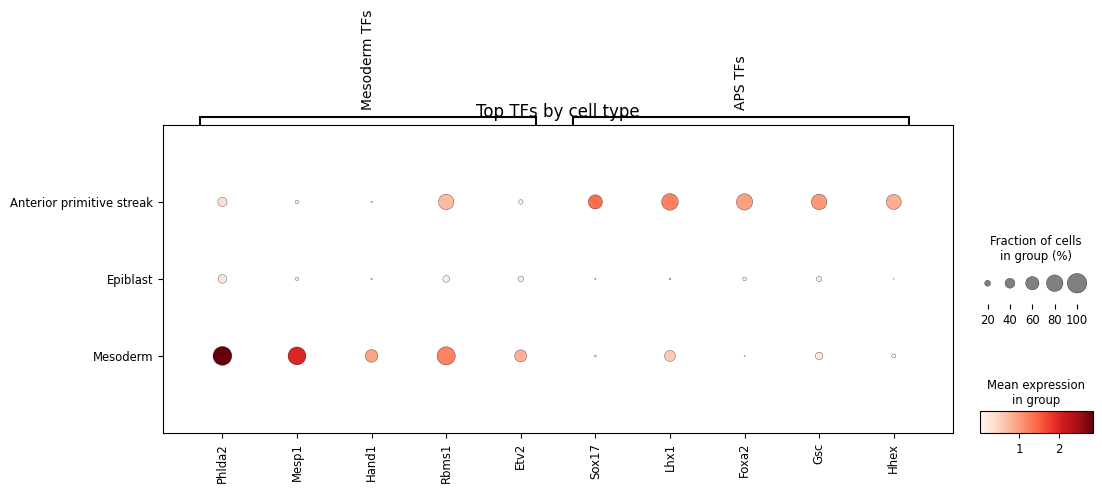

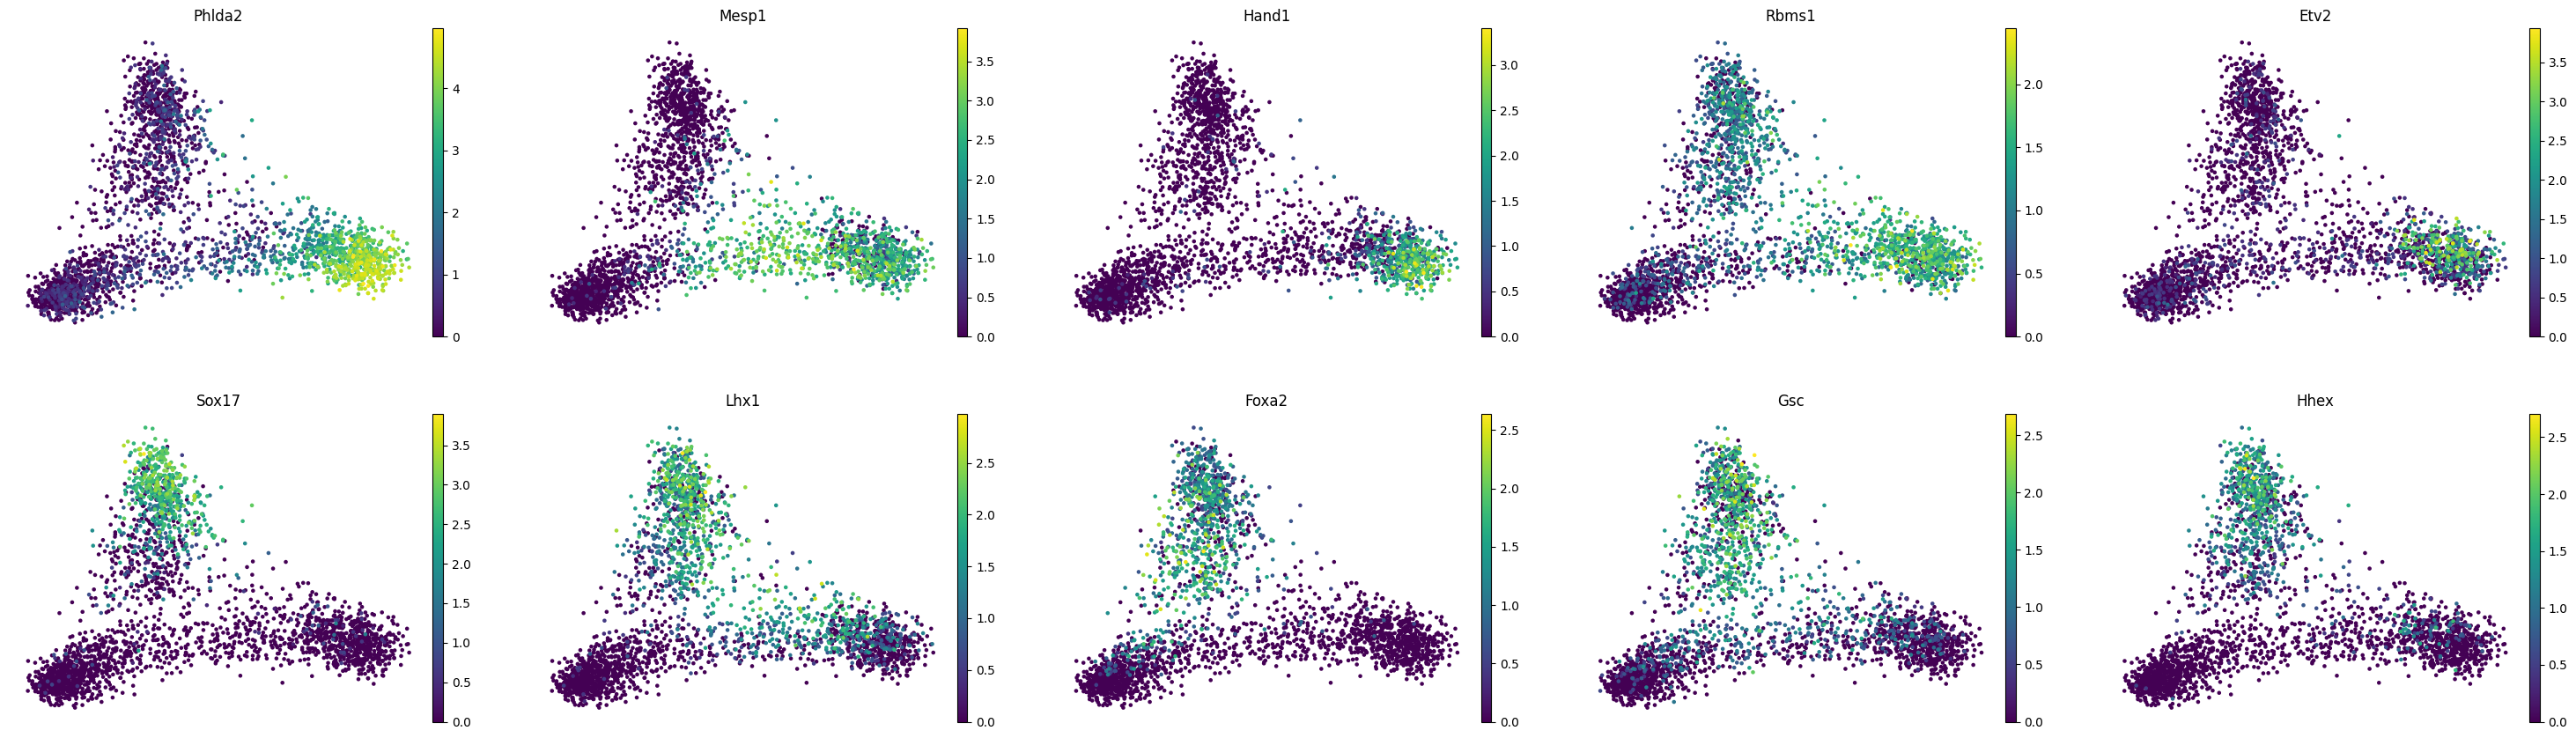

In [28]:
#I am using the top 5 mesoderm or APS TFs
top_meso_genes = top_meso_tfs.index.tolist()[:5]
top_aps_genes  = top_aps_tfs.index.tolist()[:5]

#smooth each gene's expression pattern along the principal tree to use scf.pl.trends()
scf.tl.fit(adata_hvg, n_jobs=-1)

#gene expression along pseudotime for top TFs
scf.pl.trends(adata_hvg, features=top_meso_genes, basis='pca', title='Top Mesoderm TFs along pseudotime')
scf.pl.trends(adata_hvg, features=top_aps_genes, basis='pca', title='Top APS/Endoderm TFs along pseudotime')

#dotplot to look at the top TFs across cell types (see if they are specific to a branch)
sc.pl.dotplot(adata_hvg,
              {'Mesoderm TFs': top_meso_genes,'APS TFs': top_aps_genes},
              groupby='manual_celltype',
              figsize=(12, 4),
              title='Top TFs by cell type')

#pca colored by top TF
sc.pl.pca(adata_ti, color=top_meso_genes + top_aps_genes, ncols=5, frameon=False)

### Discussion

#### Mesoderm:
The top-ranked mesoderm TFs recovered by my composite scoring system include several well-characterized regulators of mesoderm development and gastrulation, providing evidence that my criteria and application of scFates successfully identified differentiation drivers.

- Mesp1, which ranked 2nd, is important in the regulatory network for cardiovascular progenitor generation and plays critical roles in mammalian heart development and early mesodermal specification. Its presence among the top candidates is particularly significant because Mesp1 is widely regarded as one of the earliest and most specific markers of mesoderm commitment during gastrulation.

- Hand1, which ranked 3rd, was has a concentration-dependent function in mesodermal progenitors, directing differentiation toward multipotent juxta-cardiac field progenitors at low expression levels and extraembryonic mesoderm at high expression levels. The recovery of Hand1 alongside Mesp1 might suggest that my trajectory captures multiple mesoderm subtypes, including both cardiac and extraembryonic lineages.

- Rbms1, which ranked 4th, has been characterized as an RNA-binding protein required for radial migration, polarization, and differentiation of neuronal progenitors during neocortex development. Its appearance among the top mesoderm TFs suggests it may play a role in mesoderm migration through the primative streak during gastrulation.

- Phlda2, the top-ranked gene, is known to be almost exclusively expressed in extraembryonic mesoderm tissues, including the yolk sac and placenta. Its identification as the highest-scoring mesoderm TF indicates that my trajectory might be capturing extraembryonic as well as embryonic mesoderm populations.

From my visualizations:

The mesoderm branch shows strong, coordinated up-regulation of the TFs, such as Mesp1, Hand1, Etv2, Rbms1, and Phlda2, each peaking as cells move away from the epiblast and commit to mesodermal fate. This is seen in the heatmap as the trajectory with the longest pseudotime (the middle branch with the yellow pseudotime representing about a time of 17.5) has the highest expression of these markers. It appears that Mesp1 happens more in the transition to mesoderm when looking at the PCA graph. In the dot plot, epiblast cells show uniformly low expression across all TFs, consistent with their undifferentiated state. In contrast, mesoderm cells display strong and widespread activation of Phlda2, Mesp1, Hand1, Rbms1, and Etv2, reflecting a coordinated mesoderm differentation program. I noticed that in the PCA plots that Mesp1, Hand1, Etv2, and Phlda2 are only really present in the Mesoderm branch, but Rbms1 does some expression in the APS. This might be due to Rbms1's role of cell migration, which both APS and mesoderm do.

#### APS:

The top-ranked APS/endoderm TFs recovered by my composite scoring system include anterior primitive streak and endoderm development found in literature.

- Sox17, which ranked 1st, is necessary for gut endoderm morphogenesis and the assembly of the basement membrane that separates gut endoderm from mesoderm.

- Lhx1, which ranked 2nd, marks the entire definitive endoderm lineage, anterior mesendoderm, and midline progenitors through Smad4/Eomes-dependent expression. Lhx1 forms a transcriptional complex with Otx2 and Foxa2 to cooperatively regulate development of the anterior mesendoderm, node, and midline cell populations responsible for establishing the left-right body axis and head formation.

- Foxa2, which ranked 3rd, is required specifically for patterning the APS and node, with its expression dependent on FoxH1 function upstream of an activin/nodal-Smad signaling pathway. The recovery of Foxa2 alongside Lhx1 and Sox17 suggests that my trajectory captures the core regulatory network controlling APS and endoderm specification.

- Gsc, which ranked 4th, marks mesendodermal cells that give rise to both endoderm and mesoderm. Studies have shown that Gsc-expressing cells represent a bipotent mesendoderm population that diverges into definitive endoderm and mesodermal lineages, with Gsc expression serving as a critical marker of the organizer region.

From my visualizations:

The APS/endoderm branch displays a different regulatory module, with transcription factors such as Foxa2, Gsc, Hhex, Sox17, and Lhx1 increasing along the APS trajectory. The heatmap shows that the 3rd column to the right (the APS branch) has high expression of the top 5 TF genes. APS cells PCA graphs showed higher expression of endoderm and APS associated TFs,like Sox17, Foxa2, and Hhex, in the APS branch, while the TFs stay low in th eother branches. In the dot plot, epiblast cells and mesoderm showed low expression across all the APS TFs.


Summary:
My composite scoring system successfully recovered known regulators of both mesoderm (Mesp1, Hand1, Phlda2, etc.) and APS/endoderm (Sox17, Lhx1, Foxa2, etc.) development. The branch-specific activation patterns observed in visualizations align with the known functions of these TFs, while Rbms1's partial expression in both branches may reflect its role in cell migration. Together, these results validate that my TI and ranking criteria captured the core regulatory logic of gastrulation, successfully distinguishing mesoderm from APS/endoderm lineages and identifying some of their key molecular drivers.


Sources:

https://www.ncbi.nlm.nih.gov/gene/?term=22113

Habib, K., Bishayee, K., Kang, J., Sadra, A., & Huh, S. O. (2022). RNA Binding Protein Rbms1 Enables Neuronal Differentiation and Radial Migration during Neocortical Development by Binding and Stabilizing the RNA Message for Efr3a. Molecules and cells, 45(8), 588–602. https://doi.org/10.14348/molcells.2022.0044

Liang, Q., Xu, C., Chen, X., Li, X., Lu, C., Zhou, P., Yin, L., Qian, R., Chen, S., Ling, Z., & Sun, N. (2015). The roles of Mesp family proteins: functional diversity and redundancy in differentiation of pluripotent stem cells and mammalian mesodermal development. Protein & cell, 6(8), 553–561. https://doi.org/10.1007/s13238-015-0176-y

Lynch, A. T., Phillips, N., Douglas, M., Dorgnach, M., Lin, I. H., Adamson, A. D., Darieva, Z., Whittle, J., Hanley, N. A., Bobola, N., & Birket, M. J. (2025). HAND1 level controls the specification of multipotent cardiac and extraembryonic progenitors from human pluripotent stem cells. The EMBO journal, 44(9), 2541–2565. https://doi.org/10.1038/s44318-025-00409-0

Viotti, M., Nowotschin, S., & Hadjantonakis, A. K. (2014). SOX17 links gut endoderm morphogenesis and germ layer segregation. Nature cell biology, 16(12), 1146–1156. https://doi.org/10.1038/ncb3070

Hoodless, P. A., Pye, M., Chazaud, C., Labbé, E., Attisano, L., Rossant, J., & Wrana, J. L. (2001). FoxH1 (Fast) functions to specify the anterior primitive streak in the mouse. Genes & development, 15(10), 1257–1271. https://doi.org/10.1101/gad.881501

Costello, I., Nowotschin, S., Sun, X., Mould, A. W., Hadjantonakis, A. K., Bikoff, E. K., & Robertson, E. J. (2015). Lhx1 functions together with Otx2, Foxa2, and Ldb1 to govern anterior mesendoderm, node, and midline development. Genes & development, 29(20), 2108–2122. https://doi.org/10.1101/gad.268979.115

Tada, S., Era, T., Furusawa, C., Sakurai, H., Nishikawa, S., Kinoshita, M., Nakao, K., Chiba, T., & Nishikawa, S. (2005). Characterization of mesendoderm: a diverging point of the definitive endoderm and mesoderm in embryonic stem cell differentiation culture. Development (Cambridge, England), 132(19), 4363–4374. https://doi.org/10.1242/dev.02005

<a id='question-4'></a>
# 4. Discover regulators of differentiation

### TF Ranking Pipeline for Pluripotency Regulators

#### Ranking Criteria:

1. p-value
   - used the`scf.tl.test_association` from part 3 to find genes significantly associated with pseudotime
   - Lower p-value = stronger association with differentiation
   - we want a negative correlation coefficient (expression goes down as pseudotime goes up)
   - genes must show strong, statistically significant down-regulation as cells leave the epiblast. The p-value ensures we are selecting genes whose decline is not noise

2. Negative fold change from epiblast
   - TFs that are downregulated in both terminal populations (mesoderm and APS) relative to epiblast
   - we want gene is lost across differentiation (chromatin of pluripotent genes are shut off when differentiating)


3. High expression in epiblast
   - pluripotency TFs must be actively expressed in the epiblast
   - Minimum threshold: mean epiblast expression > 0.5 (log-normalized)
   - gene cannot be considered a pluripotency marker if it is not expressed in the pluripotent state.
   - prevents false positives where a gene appears “downregulated” simply because it was never expressed.

4. Pluripotency Composite Score
   - combines epiblast expression level with downregulation in both branches
   - TFs that are both highly expressed in epiblast and consistently lost across both lineages rank highest

#### Processing Steps:

1. reuse association results from question 3
2. build pluripotency ranking dataframe with:
   - FDR values
   - Mean expression in epiblast, mesoderm, and APS
   - Downregulation in each branch (mean_epi-mean_branch)
3.  `down_in_both` is the minimum of downregulation across both branches
4. Compute pluripotency composite score:
   - `-log10(FDR)+down_in_both+mean_epi`
5. Select top TFs meeting all criteria:
   - FDR < 0.05 (significant pseudotime association)
   - Downregulated in both mesoderm AND APS branches (down_in_meso > 0 and down_in_aps > 0)
   - Mean epiblast expression > 0.5 (actively expressed in epiblast)
6. Visualize top pluripotency TFs using:
   - `scf.pl.trends` for expression along pseudotime (should show decreasing expression)
   - `sc.pl.dotplot` for expression across cell types (high in epiblast, low in mesoderm/APS)
   - `sc.pl.pca` colored by TF expression


<a id='downdiff'></a>
## 4.1 TFs Downregulated Upon Differentiation

In [29]:
#filter to TFs only in HVG
sig_tfs_hvg= [tf for tf in sig_tfs if tf in adata_hvg.var_names]

#pluripotency dataFrame, using the lognorm mean expression values I calculated in question 3
pluri_stats = pd.DataFrame({'fdr': adata_hvg.var.loc[sig_tfs_hvg, 'fdr'],
                            'mean_epi': mean_epi.loc[sig_tfs_hvg].values,
                            'mean_meso': mean_meso.loc[sig_tfs_hvg].values,
                            'mean_aps': mean_aps.loc[sig_tfs_hvg].values,}, index=sig_tfs_hvg)

#downregulation in each branch relative to epiblast
#positive value means that it is downregulated in terminal population
pluri_stats['down_in_meso']= pluri_stats['mean_epi']-pluri_stats['mean_meso']
pluri_stats['down_in_aps']= pluri_stats['mean_epi']-pluri_stats['mean_aps']

#the gene must be downregulated in both branches to be a general pluripotency TF
pluri_stats['down_in_both'] = pluri_stats[['down_in_meso', 'down_in_aps']].min(axis=1)
#transform p-value into log10 (same as question 3)
pluri_stats['neg_log10_fdr'] = -np.log10(pluri_stats['fdr']+eps)

#pluripotency composite score (I decided to just make everything equal weights)
pluri_stats['pluri_score'] = (pluri_stats['neg_log10_fdr']+pluri_stats['down_in_both']+pluri_stats['mean_epi'])

<a id='rankplur'></a>
## 4.2 Rank TFs by Pluripotency Score

In [30]:
#filter out genes with very low expression in epiblast
#this makes sure that TFs are actively expressed, not just absent elsewhere
min_epi_expr = 0.5  #minimum mean log-normalized expression in epiblast

top_pluri_tfs = (pluri_stats[(pluri_stats['down_in_meso']>0) & #downregulated in mesoderm
                (pluri_stats['down_in_aps'] >0) & #downregulated in APS
                (pluri_stats['mean_epi'] > min_epi_expr) #actively expressed in epiblast
                ].sort_values('pluri_score', ascending=False).head(10))

print('Top Pluripotency TFs:\n')
print(top_pluri_tfs[['fdr', 'mean_epi', 'down_in_meso', 'down_in_aps', 'pluri_score']])

Top Pluripotency TFs:

                  fdr  mean_epi  down_in_meso  down_in_aps  pluri_score
Pou5f1   0.000000e+00  2.675323      0.930828     0.779277     9.454600
Pou3f1   0.000000e+00  0.793998      0.747061     0.691222     7.485221
Mycn    1.645642e-237  1.027022      0.220634     0.819322     7.247656


<a id='topplur'></a>
## 4.3 Visualize and Discuss Top Pluripotency Candidates

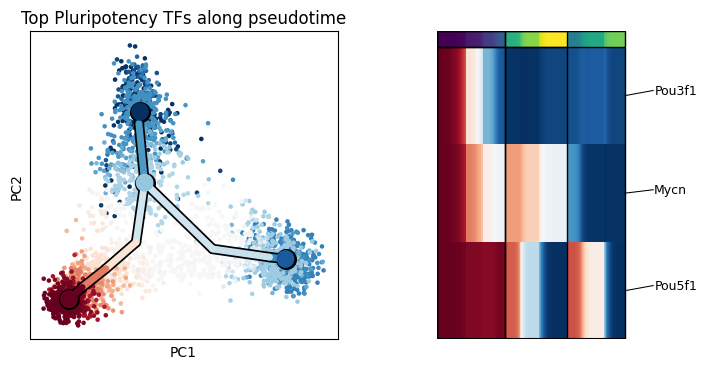

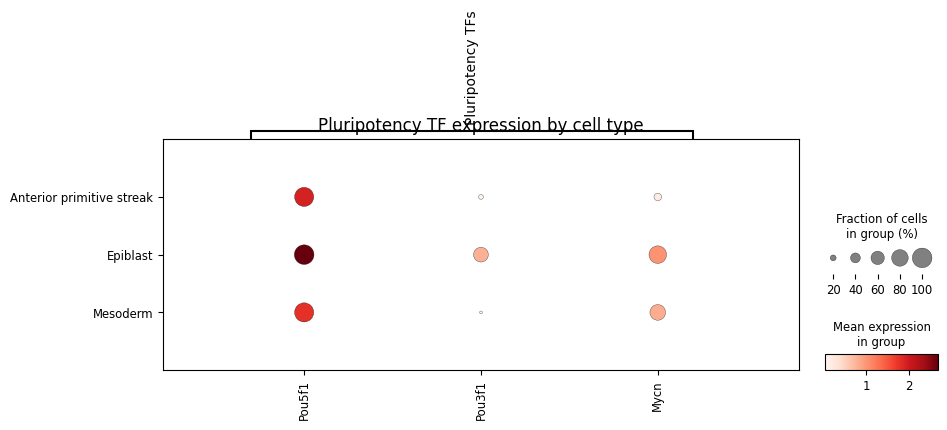

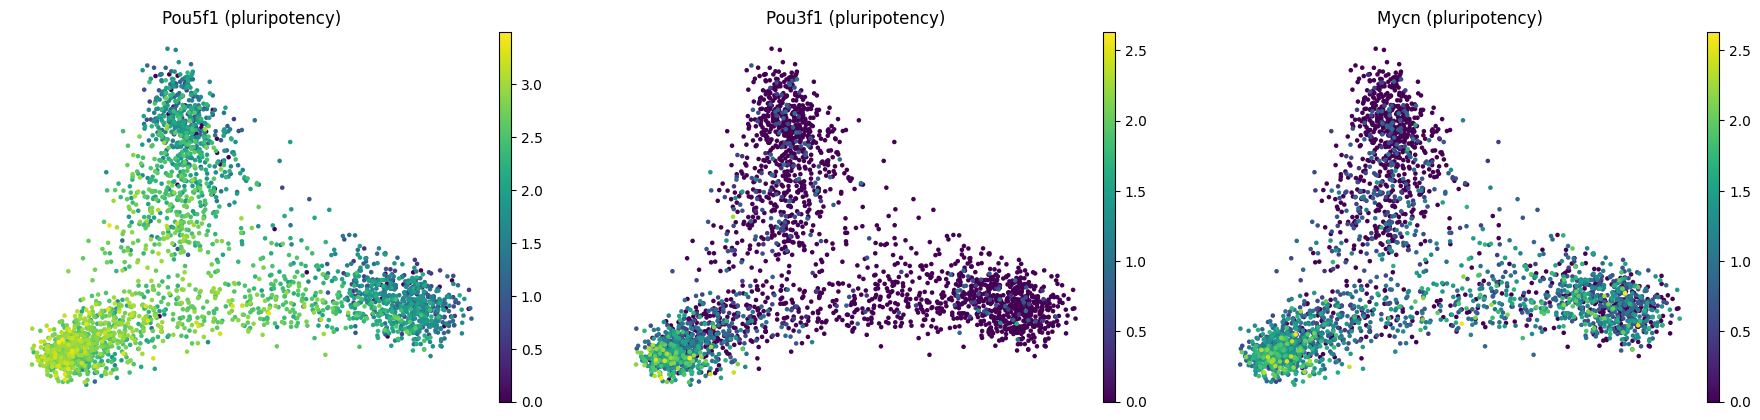

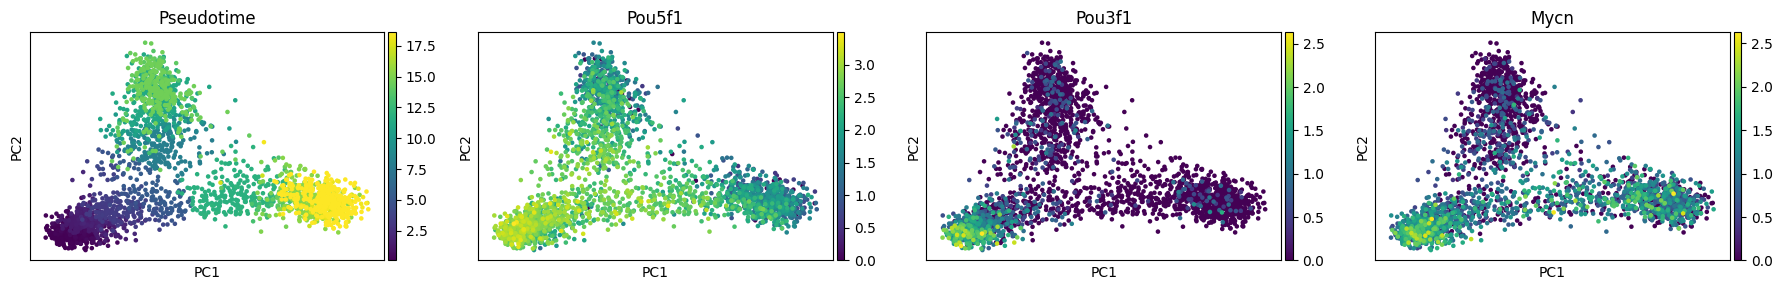

In [31]:
#get the top 3 genes since we only found 3
top_pluri_genes= top_pluri_tfs.index.tolist()[:3]

#gene expression along pseudotime for top TFs
scf.pl.trends(adata_hvg, features=top_pluri_genes, basis='pca', title='Top Pluripotency TFs along pseudotime')

#dotplot that looks if epiblast has high expression and low expression in APS/mesoderm
sc.pl.dotplot(adata_hvg,
              {'Pluripotency TFs': top_pluri_genes},
              groupby='manual_celltype',
              figsize=(10, 3),
              title='Pluripotency TF expression by cell type')

#pca colored by top TF
sc.pl.pca(adata_hvg,
          color=top_pluri_genes,
          ncols=5,
          frameon=False,
          title=[f'{g} (pluripotency)' for g in top_pluri_genes])

#pseudotime vs top pluripotency TF expression
fig, axes = plt.subplots(1, len(top_pluri_genes) + 1, figsize=(18, 3))
sc.pl.pca(adata_hvg, color='t', ax=axes[0],
          show=False, title='Pseudotime')
for i, gene in enumerate(top_pluri_genes):
    sc.pl.pca(adata_ti, color=gene, ax=axes[i+1],
              show=False, title=gene)
plt.tight_layout()
plt.show()

### Discussion

For pluripotency TF identification, I used the same HVG set selected from the entire dataset (global variance). While this captured Pou5f1 and Pou3f1, it may have excluded Utf1 due to filtering thresholds. Utf1 not appearing might be due to my minimum epiblast expression threshold (min_epi_expr = 0.5). Utf1 expression in the epiblast may fall below this cutoff, reflecting that its log-normalized values are moderate despite being a well-established pluripotency marker. A lower threshold would might recover Utf1, but at the risk of including false positives from lowly expressed genes.

Pou5f1 (Oct4), which ranked 1st, plays crucial roles in maintaining pluripotency in embryonic stem cells and epiblast cells. It's important for preserving the undifferentiated state of the epiblast.

Pou3f1, which ranked 2nd, has been shown to be a direct transcriptional target of nanog, with its expression negatively correlated with Nanog during early differentiation. Nanog actively represses Pou3f1 at the onset of gastrulation, which aligns with my finding that Pou3f1 is downregulated in both mesoderm and APS branches as cells commit to differentiated fates.

Mycn, which ranked 3rd, has been directly implicated in the transcriptional regulation of pluripotency-associated genes in pluripotent stem cells. MYC family transcription factors, including MYCN, are involved in self-renewal, maintenance of pluripotency, and control of cell fate decisions during early embryonic development.


From my visualizations:

The pseudotime plot shows that Pou5f1 (Oct4), Pou3f1, and Mycn are all highly expressed at the root of the trajectory, where epiblast cells reside, and then decline steadily as cells move toward either the mesoderm or APS branches. The heatmap also shows that all three TFs show strong expression early in pseudotime (left-most column), followed by a coordinated loss of expression as differentiation progresses. This is exactly the pattern expected for core pluripotency regulators, which must be silenced for lineage commitment to proceed. The dot plot further validates this interpretation by showing that these TFs are highly expressed in epiblast, but nearly absent in both mesoderm and APS, consistent with their role in maintaining the undifferentiated state. We see form the PCA plots that all three genes are only really expressed in the epiblast branch (the root node) and happen early in pseudotime. Together, these visualizations show that the TFs identified by my ranking pipeline are high in the root, downregulated in both branches, and strongly associated with early pseudotime. Combined with the literature showing that Pou5f1 maintains pluripotency, Pou3f1 is repressed by Nanog during gastrulation, and Mycn regulates self-renewal, these visualizations confirm that my ranking pipeline successfully identified biologically reasonable, pluripotency-promoting transcription factors.

Sources:

Roshan, M. M., Azizi, H., & Sojoudi, K. (2024). A novel investigation of NANOG and POU5F1 associations in the pluripotent characterization of ES-like and epiblast cells. Scientific reports, 14(1), 24092. https://doi.org/10.1038/s41598-024-75529-4

Barral, A., Rollan, I., Sanchez-Iranzo, H., Jawaid, W., Badia-Careaga, C., Menchero, S., Gomez, M. J., Torroja, C., Sanchez-Cabo, F., Göttgens, B., Manzanares, M., & Sainz de Aja, J. (2019). Nanog regulates Pou3f1 expression at the exit from pluripotency during gastrulation. Biology open, 8(11), bio046367. https://doi.org/10.1242/bio.046367

Chappell, J., & Dalton, S. (2013). Roles for MYC in the establishment and maintenance of pluripotency. Cold Spring Harbor perspectives in medicine, 3(12), a014381. https://doi.org/10.1101/cshperspect.a014381

<a id='question-5'></a>
# 5. Compare CytoTRACE to pseudotime


### CytoTRACE vs scFates Pseudotime Comparison Pipeline

Overview:
- CytoTRACE: estimates cellular potency from transcriptional diversity (number of genes expressed per cell). More potent cells express more genes.
- scFates pseudotime: measures the position along an inferred differentiation trajectory.


1. Compute CytoTRACE using CellRank's CytoTRACEKernel
   - raw counts are extracted from the original `adata` object and subset to the same cells present in `adata_ti` (VE-removed cells)
   - neighbors are recomputed on the raw count data (using the same parameters as the original pipeline: `n_neighbors=20`, `n_pcs=10`)
    - `ctk=cr.kernels.CytoTRACEKernel(adata_raw)` initializes the kernel on the raw count object
    - `ctk.compute_cytotrace(layer='X')` computes CytoTRACE scores using the raw counts stored in `.X`
    - Scores are transferred to `adata_ti.obs['cytotrace']=adata_raw.obs['ct_score'].values`
    - CytoTRACE score interpretation: higher = more potent (less differentiated)

2. UMAP and PCA
     - Row 1 (UMAP): CytoTRACE score, scFates pseudotime, Cell type
     - Row 2 (PCA): CytoTRACE score, scFates pseudotime, Cell type
   - expected pattern if measures agree:
     - Epiblast: high CytoTRACE, low pseudotime
     - APS/Mesoderm: low CytoTRACE, high pseudotime

3. correlation analysis
   - compute Spearman correlation (rank-based, used in non-linearity)
    - I am not not sure the linearity of the correlation (otherwise I would have used Pearson)
   - global correlation across all cells
   - per-branch correlation (epiblast, mesoderm, APS segments)
   - per-cell type correlation

4. Scatter plot visualization

5. Boxplot analysis
   - CytoTRACE score distribution by cell type

6. Further analysis: n_genes correlation
   - Add `n_genes` to obs (number of expressed genes per cell)
   - compute correlation between n_genes and CytoTRACE
   - compute correlation between n_genes and pseudotime
   - visualize n_genes, CytoTRACE, and pseudotime on PCA
   - B=bin pseudotime and plot mean n_genes per bin


<a id='cyto'></a>
## 5.1 Running CytoTRACE

In [58]:
np.random.seed(0)
random.seed(0)

cells_in_ti=adata_ti.obs_names

#get all genes from original adata (not filtered)
adata_raw=adata[cells_in_ti, :].copy()

#compute neighbors on the raw data
sc.pp.neighbors(adata_raw, n_neighbors=20, n_pcs=10)

ctk = cr.kernels.CytoTRACEKernel(adata_raw)
ctk.compute_cytotrace(layer='X')

#get the cytoTRACE scores and transfer it to adata_ti
adata_ti.obs['cytotrace'] = adata_raw.obs['ct_score'].values

print('\nCytoTRACE results:')
print(adata_ti.obs[['cytotrace', 't', 'manual_celltype']].describe())
print(adata_ti.obs.groupby('manual_celltype')['cytotrace'].mean())


CytoTRACE results:
         cytotrace            t
count  2778.000000  2778.000000
mean      0.263800     9.473087
std       0.140056     6.395827
min       0.000000     0.089888
25%       0.165338     3.262786
50%       0.251950    11.221017
75%       0.345333    14.574742
max       1.000000    18.593299
manual_celltype
Anterior primitive streak    0.253595
Epiblast                     0.269328
Mesoderm                     0.268024
Name: cytotrace, dtype: float64


<a id='graph'></a>
## 5.2 CytoTRACE vs Pseudotime on UMAP and PCA

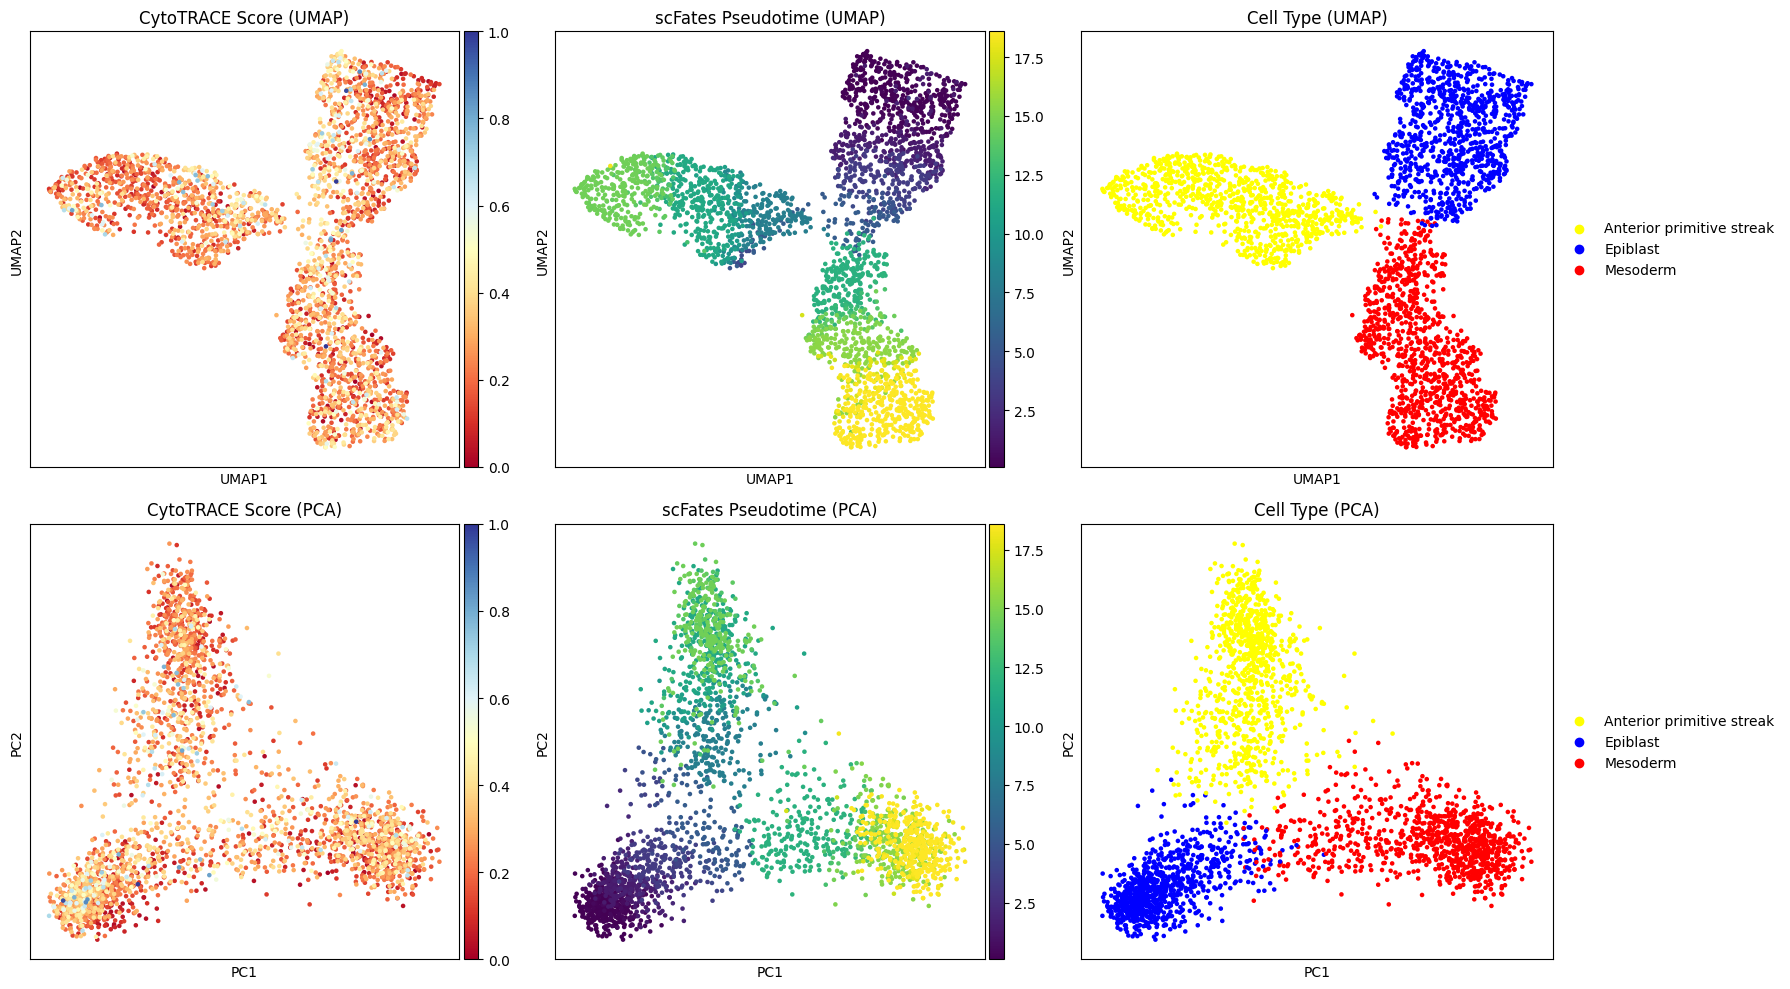

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#compare umap of Cytotrace score, pseudotime, and my manual annotations
sc.pl.umap(adata_ti, color='cytotrace', ax=axes[0, 0], show=False, title='CytoTRACE Score (UMAP)', color_map='RdYlBu')

sc.pl.umap(adata_ti, color='t', ax=axes[0, 1], show=False, title='scFates Pseudotime (UMAP)', color_map='viridis')

sc.pl.umap(adata_ti,
           color='manual_celltype',
           ax=axes[0, 2], show=False,
           title='Cell Type (UMAP)',
           palette={'Epiblast': 'blue',
                    'Mesoderm': 'red',
                    'Anterior primitive streak': 'yellow'})

#compare pca of Cytotrace score, pseudotime, and my manual annotations
sc.pl.pca(adata_ti, color='cytotrace', ax=axes[1, 0], show=False, title='CytoTRACE Score (PCA)', color_map='RdYlBu')

sc.pl.pca(adata_ti, color='t', ax=axes[1, 1], show=False, title='scFates Pseudotime (PCA)', color_map='viridis')

sc.pl.pca(adata_ti, color='manual_celltype',
          ax=axes[1, 2], show=False,
          title='Cell Type (PCA)',
          palette={'Epiblast': 'blue',
                    'Mesoderm': 'red',
                    'Anterior primitive streak': 'yellow'})

plt.tight_layout()
plt.show()

 In both embeddings, CytoTRACE seem to assign equal stemness scores to epiblast cells, APS, and mesoderm cells (though, epiblast might be slightly higher. I see some scores in the 0.4 and 0.5 range that I don't see in the other cells). The overall cytoTRACE score is really low in every cell type, which is around 0 to 0.2. scFates pseudotime showed low pseudotime values concentrated in the epiblast region and higher values extending along the two terminal branches. The cell type overlays aligned with these gradients, revealing a clear Y-shaped bifurcation in which epiblast forms the root and APS and mesoderm diverge into distinct arms. Although UMAP shows more branch separation relative to PCA, the overall structure is preserved across methods (mesoderm, epliblast, and APS are well seperated).

CytoTRACE assigned nearly identical stemness scores to epiblast (0.269), mesoderm (0.268), and APS (0.254), indicating that transcriptional complexity remains uniformly low across all cell types in this dataset. Consequently, CytoTRACE fails to distinguish undifferentiated from differentiated populations, while scFates pseudotime successfully captures the developmental progression from epiblast to terminal fates. This discrepancy shows how CytoTRACE and pseudotime measure fundamentally different properties: transcriptional complexity versus directed developmental progression along an anchored trajectory.

<a id='corr'></a>
## 5.3 Correlation Analysis

In [60]:
corr, pval = spearmanr(adata_ti.obs['cytotrace'], adata_ti.obs['t'])
print(f'Global Spearman correlation (CytoTRACE vs pseudotime): corr={corr:.3f}, p={pval:.2e}')
print('Note: expected negative correlation (high potency = low pseudotime)\n')

#per-branch correlation
#Branch-specific correlations help identify if disagreement is specific to one lineage.
print('Available segments:', adata_ti.obs['seg'].unique())

for seg_id, seg_name in [('1', 'Epiblast'),
                          ('2', 'Mesoderm'),
                          ('3', 'APS')]:
    #filter for cells in a specific branch
    mask = adata_ti.obs['seg'] == seg_id
    if mask.sum() < 10:
        print(f'  {seg_name} (seg {seg_id}): not enough cells (n={mask.sum()})')
        continue
    corr_seg, pval_seg = spearmanr(adata_ti.obs.loc[mask, 'cytotrace'], adata_ti.obs.loc[mask, 't'])
    print(f'  {seg_name} (seg {seg_id}): corr={corr_seg:.3f}, p={pval_seg:.2e}, n={mask.sum()}')

#per cell-type correlation (same as per-branch)
print()
for ct_name in ['Epiblast', 'Mesoderm', 'Anterior primitive streak']:
    mask = adata_ti.obs['manual_celltype'] == ct_name
    if mask.sum() < 10:
        continue
    corr_ct, pval_ct = spearmanr(adata_ti.obs.loc[mask, 'cytotrace'], adata_ti.obs.loc[mask, 't'])
    print(f'  {ct_name}: corr={corr_ct:.3f}, p={pval_ct:.2e}, n={mask.sum()}')



Global Spearman correlation (CytoTRACE vs pseudotime): corr=-0.056, p=3.41e-03
Note: expected negative correlation (high potency = low pseudotime)

Available segments: ['1', '2', '3']
Categories (3, object): ['1', '2', '3']
  Epiblast (seg 1): corr=-0.050, p=1.11e-01, n=999
  Mesoderm (seg 2): corr=-0.051, p=1.22e-01, n=926
  APS (seg 3): corr=-0.174, p=3.31e-07, n=853

  Epiblast: corr=-0.091, p=5.93e-03, n=916
  Mesoderm: corr=-0.079, p=1.44e-02, n=966
  Anterior primitive streak: corr=-0.165, p=7.29e-07, n=896


The Spearman correlation between CytoTRACE and scFates pseudotime showed a weak (almost no) but statistically significant global negative correlation (corr = -0.056, p = 3.41e-03), indicating that cells with higher potency tend to have lower pseudotime values, though the relationship is not very strong. However, this global correlation masks substantial branch-specific variation.

Within the epiblast branch (segment 1), there was essentially no correlation (corr = -0.050, p = 0.111), implying that CytoTRACE scores do not vary with pseudotime among undifferentiated epiblast cells. The mesoderm branch (segment 2) showed no correlation (corr= -0.051, p=0.122), while the APS branch (segment 3) showed the strongest negative correlation (corr=-0.174, p= 3.31e-07). This pattern was validated with my manual annotations, with epiblast showing weak/no correlation (corr=-0.091, p=0.00593), mesoderm showing no correlation (corr=-0.079, p=0.0144), and APS showing the strongest negative correlation (corr=-0.165, p=7.29e-07). These results suggest that CytoTRACE captures a meaningful potency gradient primarily within the APS lineage, while epiblast and mesoderm cells are transcriptionally homogeneous with respect to potency. The consistent negative direction across all comparisons supports the biological expectation that high potency associates with earlier developmental time, though the weak (almost no) overall correlation shows that CytoTRACE and pseudotime measure fundamentally different properties of cellular state. Combined with the CytoTRACE scores being almost identical across cell types (epiblast 0.269, mesoderm 0.268, APS 0.254), CytoTRACE would struggle to identify a clear root in the dataset. This validates that we should probably use scFates with a biologically informed root (epiblast) rather than relying on CytoTRACE.

<a id='boxscat'></a>
## 5.4 CytoTRACE vs. Pseudotime Scatter Plot and Boxplot

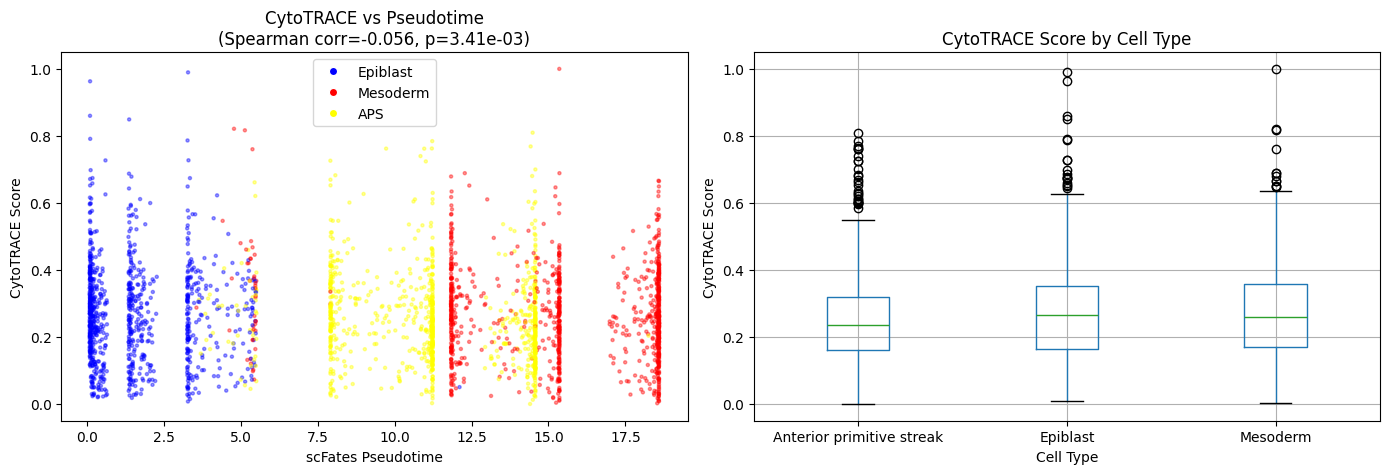

In [61]:
fig, axes=plt.subplots(1, 2, figsize=(14, 5))

colors= adata_ti.obs['manual_celltype'].map({'Epiblast': 'blue',
                                             'Mesoderm': 'red',
                                             'Anterior primitive streak': 'yellow'})

axes[0].scatter(adata_ti.obs['t'], adata_ti.obs['cytotrace'], c=colors, alpha=0.4, s=5)
axes[0].set_xlabel('scFates Pseudotime')
axes[0].set_ylabel('CytoTRACE Score')
axes[0].set_title(f'CytoTRACE vs Pseudotime\n(Spearman corr={corr:.3f}, p={pval:.2e})')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Epiblast'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Mesoderm'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', label='APS'),]
axes[0].legend(handles=legend_elements)

#per-cell type boxplot of CytoTRACE scores
adata_ti.obs.boxplot(column='cytotrace', by='manual_celltype', ax=axes[1])
axes[1].set_title('CytoTRACE Score by Cell Type')
axes[1].set_xlabel('Cell Type')
axes[1].set_ylabel('CytoTRACE Score')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [62]:
print(adata_ti.obs.groupby('manual_celltype')['cytotrace'].median())

manual_celltype
Anterior primitive streak    0.235536
Epiblast                     0.264592
Mesoderm                     0.260007
Name: cytotrace, dtype: float64


The scatter plot again shows a weak but statistically significant negative correlation between CytoTRACE score and pseudotime, indicating that differentiation potential declines only weakly as cells progress developmentally. Epiblast cells cluster at early pseudotime values (0-5), APS cells appear mid-trajectory (pseudotime 8-15), and mesoderm cells predominantly occupy later pseudotime values (11-18). The scatter plot displays distinct vertical 'stripes' or bands rather than a continuous cloud of points. This striping occurs because scFates assigns pseudotime values based on a graph structure (decision tree) where cells are projected onto discrete nodes or edges, causing multiple cells to share identical pseudotime coordinates. Each vertical line represents a group of cells that the algorithm considers to be at the same developmental stage, and the vertical spread within each line shows that even at identical pseudotime positions, cells can exhibit substantial variation in CytoTRACE scores, which shows heterogeneity in transcriptional complexity and potency.

The box plot shows that epiblast has the highest median CytoTRACE score (0.264), followed by mesoderm (0.260) and APS (0.236), though all three cell types retain relatively low scores, suggesting that most cells in this dataset have modest transcriptional complexity and are already committed to differentiated fates. We see that the distribution is skewed, with a cluster of low-scoring cells and a long tail of high-value outliers (the black circles). These high outliers may represent a small subpopulation of cells that retain higher developmental potency, such as epiblast cells that have not yet initiated differentiation programs, or they could reflect technical artifacts such as cells with unusually high library size or gene detection rates.

<a id='ngenes'></a>
## 5.5 n_genes Correlation

Since CytoTRACE is driven primarily by the number of genes expressed per cell
(transcriptional diversity), I directly inspect whether n_genes tracks with
pseudotime.


n_genes vs CytoTRACE: corr=0.965, p=0.00e+00
n_genes vs pseudotime: corr=-0.008, p=6.65e-01


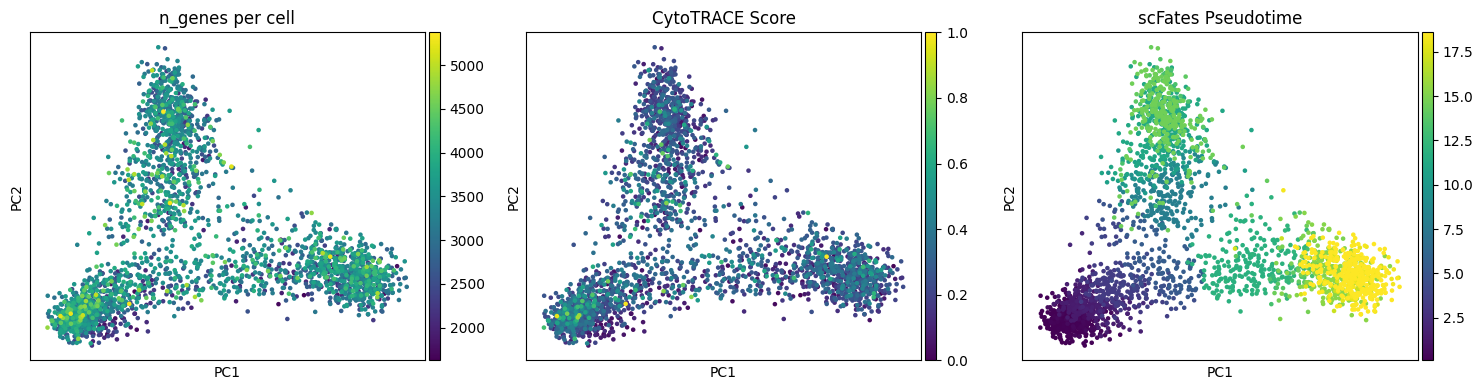

ct_pseudotime: {'count': 2778.0, 'mean': 0.3137708706272911, 'std': 0.16202522475619727, 'min': 0.0}
ct_num_exp_genes: {'count': 2778.0, 'mean': 3249.8905687545, 'std': 627.027241217627, 'min': 1624.0}


In [63]:

#correlation between n_genes and CytoTRACE or pseudotime
corr_ng, pval_ng = spearmanr(adata_ti.obs['n_genes'], adata_ti.obs['cytotrace'])
print(f'\nn_genes vs CytoTRACE: corr={corr_ng:.3f}, p={pval_ng:.2e}')
corr_ng_t, pval_ng_t = spearmanr(adata_ti.obs['n_genes'], adata_ti.obs['t'])
print(f'n_genes vs pseudotime: corr={corr_ng_t:.3f}, p={pval_ng_t:.2e}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.pca(adata_ti, color='n_genes', ax=axes[0], show=False, title='n_genes per cell')
sc.pl.pca(adata_ti, color='cytotrace', ax=axes[1], show=False, title='CytoTRACE Score')
sc.pl.pca(adata_ti, color='t', ax=axes[2], show=False, title='scFates Pseudotime')
plt.tight_layout()
plt.show()

print(f"ct_pseudotime: {adata_ti.obs['ct_pseudotime'].describe().iloc[:4].to_dict()}")
print(f"ct_num_exp_genes: {adata_ti.obs['ct_num_exp_genes'].describe().iloc[:4].to_dict()}")

The near-perfect correlation between n_genes and CytoTRACE (corr=0.965) confirms that CytoTRACE primarily measures transcriptional complexity. The absence of correlation between n_genes and pseudotime (corr=-0.008) demonstrates that the number of expressed genes does not decrease during gastrulation in this dataset, with epiblast, mesoderm, and APS cells all expressing approximately 3,250 genes on average. This explains the weak correlation between CytoTRACE and pseudotime (corr = -0.056): since transcriptional complexity remains constant along the trajectory, CytoTRACE cannot distinguish early from late developmental stages, while scFates pseudotime captures directed differentiation progress through changes in lineage-specific gene expression rather than global gene count.

In [65]:
#check if n_genes plateaus at high pseudotime
adata_ti.obs['pseudotime_bin']=pd.cut(adata_ti.obs['t'], bins=10)
print(adata_ti.obs.groupby('pseudotime_bin')['n_genes'].mean())

pseudotime_bin
(0.0714, 1.94]      3248.481366
(1.94, 3.791]       3166.189474
(3.791, 5.641]      3271.860606
(5.641, 7.491]              NaN
(7.491, 9.342]      3323.555000
(9.342, 11.192]     3279.283871
(11.192, 13.042]    3236.723558
(13.042, 14.893]    3250.824468
(14.893, 16.743]    3177.636792
(16.743, 18.593]    3284.035714
Name: n_genes, dtype: float64


Binning pseudotime into 10 equal intervals showed that the mean number of expressed genes per cell remains mostly constant (3,200-3,300) from the epiblast root (pseudotime 0-2) through the terminal mesoderm and APS branches (pseudotime 16-19). This flat relationship explains the weak correlation between n_genes and pseudotime (corr = -0.008) and also the weak correlation between CytoTRACE and pseudotime (corr = -0.056), as CytoTRACE scores are primarily determined by n_genes (corr = 0.965). Biologically, this means that during early gastrulation, committed mesoderm and APS cells maintain transcriptional complexity comparable to epiblast cells, suggesting they remain in a highly plastic state even after lineage specification.

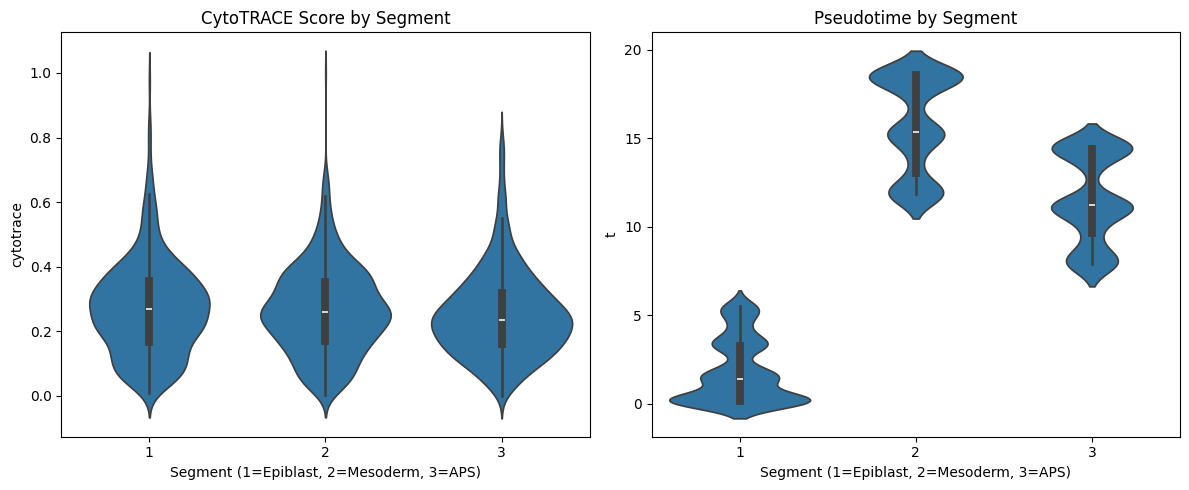

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: CytoTRACE by segment
sns.violinplot(x='seg', y='cytotrace', data=adata_ti.obs, ax=axes[0])
axes[0].set_xlabel('Segment (1=Epiblast, 2=Mesoderm, 3=APS)')
axes[0].set_title('CytoTRACE Score by Segment')

# Plot 2: Pseudotime by segment (using seaborn)
sns.violinplot(x='seg', y='t', data=adata_ti.obs, ax=axes[1])
axes[1].set_xlabel('Segment (1=Epiblast, 2=Mesoderm, 3=APS)')
axes[1].set_title('Pseudotime by Segment')

plt.tight_layout()
plt.show()

These violin plots provide a more detailed view of the data density. TheCytoTRACE score by segment reveals that the widest part of each violin sits at the bottom around 0.2-0.3, indicating that the vast majority of cells have low CytoTRACE scores. The thin necks stretching up toward 1.0 represent a smaller population of cells with high differentiation potential, and these outliers are more seen in the epiblast cells (some in mesoderm, but the distribution is thinner) The pseudotime by segment shows distinct differences between segments. Pseudotime clearly shows that epiblast is early in pseudotime space while the mesoderm and APS are later. These violin plots explain the weak correlation between CytoTRACE and pseudotime: the majority of cells across all segments cluster at low CytoTRACE scores (0.2-0.3), with only a thin tail of high-scoring cells, meaning CytoTRACE cannot distinguish epiblast from mesoderm or APS based on potency scores alone.

<a id='results'></a>
## 5.6 Results

CytoTRACE and scFates pseudotime show weak agreement in this dataset. The global Spearman correlation between CytoTRACE scores and pseudotime was corr = -0.056 (p=3.41e-03). While statistically significant due to the large sample size (n = 2,778 cells), the magnitude of the correlation is weak (almost none), which tells us that the two methods capture fundamentally different properties of cellular state.

Where do they diagree:

- CytoTRACE primarily measures transcriptional complexity. The near-perfect correlation between n_genes and CytoTRACE (corr = 0.965, p = 0.00) confirms that CytoTRACE scores are almost entirely determined by the number of genes expressed per cell, rather than lineage-specific transcriptional programs.

- Transcriptional complexity remains constant across pseudotime. Binning pseudotime into ten intervals revealed that the mean number of expressed genes remains constant (3,200-3,300) from the epiblast root through the terminal mesoderm and APS branches. The correlation between n_genes and pseudotime was near zero (corr = -0.008, p = 0.67).

- The disagreement is consistent across all branches. Per-branch correlation analysis showed that the weak global correlation masks minimal branch-specific variation. Epiblast showed no correlation, mesoderm showed very weak (to no) negative correlation, and APS showed the strongest but still weak negative correlation. This pattern was confirmed using manual cell type annotations.

Biological Interpretation:

The weak agreement between CytoTRACE and scFates pseudotime show that these two methods measure fundamentally different properties. CytoTRACE quantifies transcriptional complexity (gene count), which remains uniformly high throughout early gastrulation as mesoderm and APS cells maintain open chromatin and diverse gene expression. scFates pseudotime, in contrast, measures directed developmental progression along a trajectory anchored to the epiblast root, capturing changes in lineage-specific gene expression programs that occur independently of global gene count. Thus, while both methods correctly identify epiblast as the starting point, they diverge in their assessment of terminal populations because transcriptional complexity does not decrease during early differentiation in this dataset.

Lineage bias is determined by DNA methylation patterns that prime epiblast cells toward specific fates. While this epigenetic priming alters which genes are accessible, my analysis shows that the total number of expressed genes per cell remains constant (3,200-3,300) across epiblast, mesoderm, and APS. This suggests that differentiation during early gastrulation involves transcriptional reprogramming, which is the closing lineage-inappropriate genes while opening lineage-specific ones. This is different than a global reduction in transcriptional complexity. This explains why CytoTRACE, which primarily measures total gene count, fails to distinguish these populations, while scFates successfully captures lineage-specific gene activation patterns.


Source:

Menezes, N.A., Peterson, K.J., Guo, X. et al. Cell-context response to germ layer differentiation signals is predetermined by the epigenome in regionalized epiblast populations. Nat Commun 16, 5000 (2025). https://doi.org/10.1038/s41467-025-60348-6